<a href="https://colab.research.google.com/github/akshayjoseph1999-maker/Akshay/blob/main/A_Comparative_Analysis_of_Entanglement_Dynamics_and_Metric_Reliability_Across_Five_Quantum_Computational_Paradigms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.4 MB/s eta 0:00:00


QFT analysis





n=2: final <S1> (ideal)=0.600876, (noisy)=0.748894, F_GHZ(ideal)=0.625000, F_GHZ(noisy)=0.542751, S_half(ideal)=0.600876, S_half(noisy)=0.767389
n=3: final <S1> (ideal)=0.499845, (noisy)=0.731201, F_GHZ(ideal)=0.445083, F_GHZ(noisy)=0.334007, S_half(ideal)=0.665332, S_half(noisy)=0.864434
n=4: final <S1> (ideal)=0.397915, (noisy)=0.744129, F_GHZ(ideal)=0.242864, F_GHZ(noisy)=0.150998, S_half(ideal)=0.273237, S_half(noisy)=1.497431
n=5: final <S1> (ideal)=0.323888, (noisy)=0.755626, F_GHZ(ideal)=0.124099, F_GHZ(noisy)=0.065527, S_half(ideal)=0.282638, S_half(noisy)=1.645585
n=6: final <S1> (ideal)=0.271264, (noisy)=0.785127, F_GHZ(ideal)=0.062387, F_GHZ(noisy)=0.027400, S_half(ideal)=0.097301, S_half(noisy)=2.456441
n=7: final <S1> (ideal)=0.232846, (noisy)=0.804450, F_GHZ(ideal)=0.031236, F_GHZ(noisy)=0.011783, S_half(ideal)=0.098224, S_half(noisy)=2.585427
n=8: final <S1> (ideal)=0.203823, (noisy)=0.830327, F_GHZ(ideal)=0.015623, F_GHZ(noisy)=0.005125, S_half(ideal)=0.031081, S_half(n

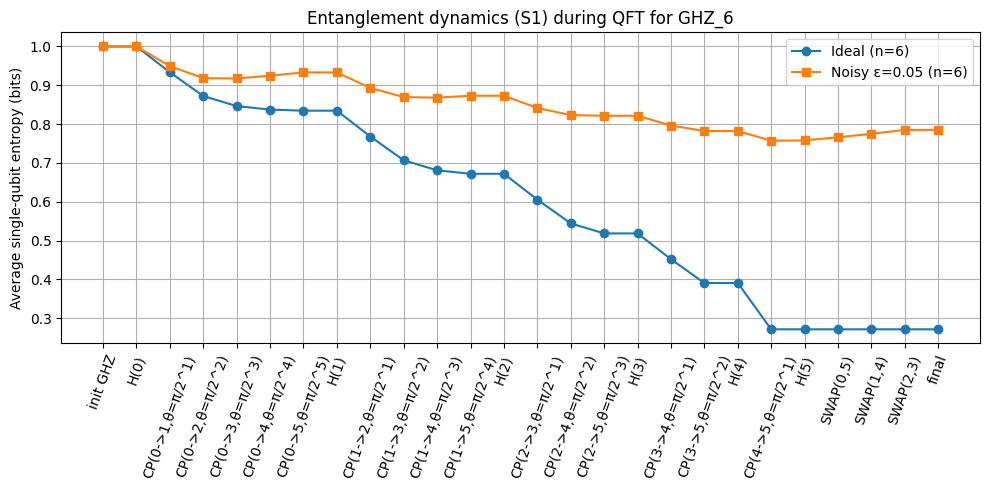

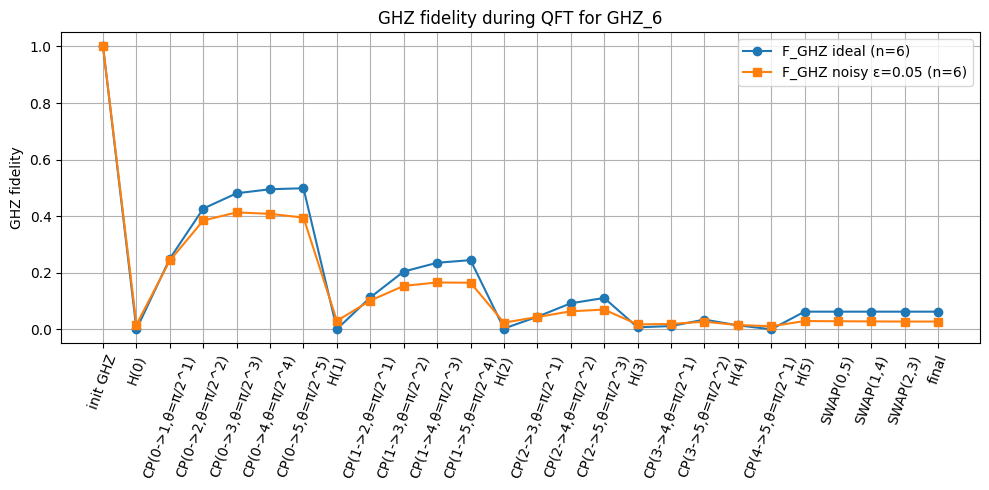

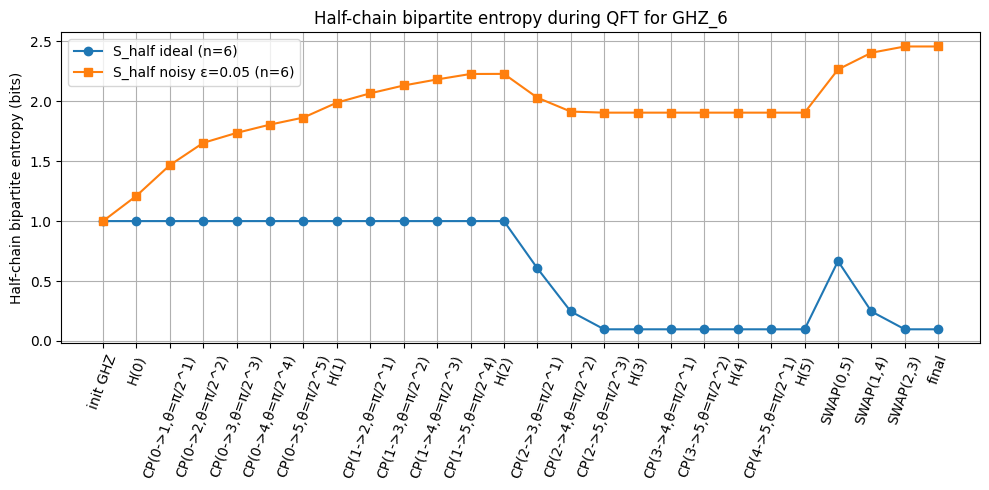

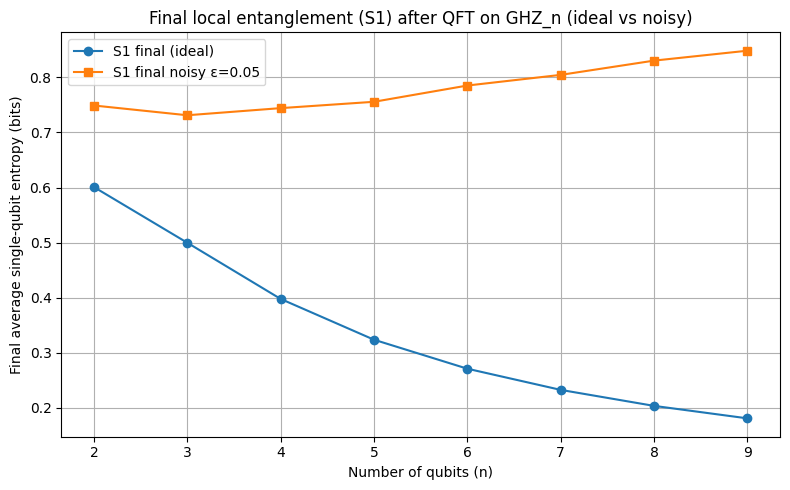

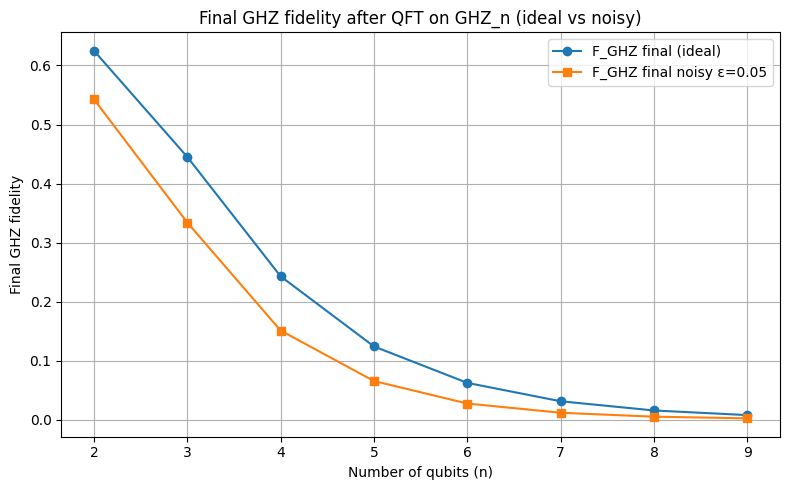

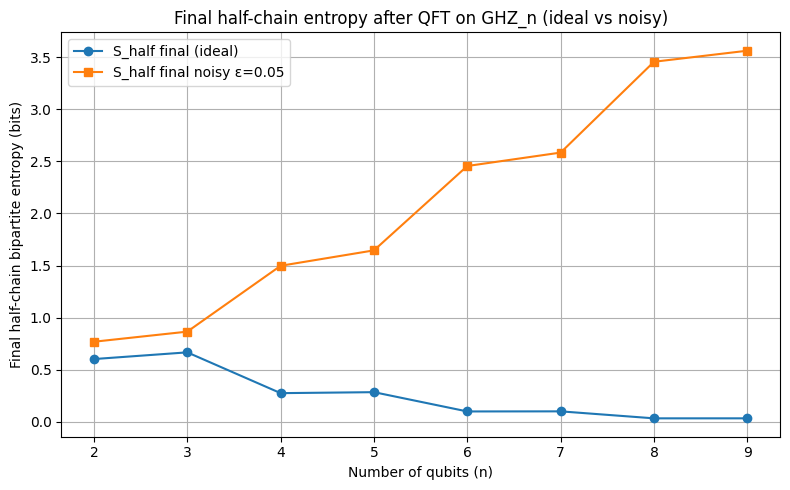

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# ---------------- Helper functions ----------------
def partial_trace_single(rho, n, q):
    """Reduced density matrix of qubit q (MSB-first convention)."""
    rho_tensor = rho.reshape([2]*(2*n))
    ket_order = [q] + [i for i in range(n) if i != q]
    bra_order = [q+n] + [i+n for i in range(n) if i != q]
    perm = ket_order + bra_order
    rho_perm = np.transpose(rho_tensor, perm)
    dim_rem = 2**(n-1)
    rho_reshaped = rho_perm.reshape((2, dim_rem, 2, dim_rem))
    return np.trace(rho_reshaped, axis1=1, axis2=3)

def von_neumann_entropy(rho):
    # numerical hygiene
    rho = 0.5*(rho + rho.conj().T)
    vals = np.linalg.eigvalsh(rho)
    vals = np.clip(np.real(vals), 0, 1)
    vals = vals[vals > 1e-12]
    return -np.sum(vals*np.log2(vals)) if len(vals) > 0 else 0.0

def avg_single_qubit_entropy(rho, n):
    return float(np.mean([von_neumann_entropy(partial_trace_single(rho, n, q)) for q in range(n)])) if n>0 else 0.0

# ---- general partial trace (for subsystems) ----
def partial_trace(rho, keep, n):
    """
    Trace out all qubits except those in 'keep' (list of indices, MSB-first).
    """
    keep = sorted(keep)
    trace = [i for i in range(n) if i not in keep]

    dims = [2]*n
    rho_reshaped = rho.reshape(dims + dims)  # (ket dims | bra dims)
    dims_per_block = n
    for t in sorted(trace, reverse=True):
        rho_reshaped = np.trace(rho_reshaped, axis1=t, axis2=t + dims_per_block)
        dims_per_block -= 1
    dim_keep = 2**len(keep)
    return rho_reshaped.reshape(dim_keep, dim_keep)

# ---- half-chain bipartite entropy S_A|B ----
def bipartite_half_entropy(rho, n):
    """
    Bipartite entropy between first half (A) and second half (B).
    A = qubits [0 .. half-1] in MSB-first convention.
    """
    half = n // 2
    if half == 0 or half == n:
        return 0.0
    keep_A = list(range(half))
    rho_A = partial_trace(rho, keep_A, n)
    return von_neumann_entropy(rho_A)

# ---------- GHZ state & fidelity ----------
def ghz_state(n):
    dim = 2**n
    v = np.zeros(dim, dtype=complex)
    v[0]  = 1/np.sqrt(2)
    v[-1] = 1/np.sqrt(2)
    return v

def ghz_fidelity(rho, n):
    g = ghz_state(n)
    return float(np.real_if_close(g.conj().T @ rho @ g))

# ---------- 1-qubit depolarizing (Kraus) ----------
def depolarizing_kraus(epsilon):
    """
    E(ρ) = (1-ε)ρ + (ε/3)(XρX + YρY + ZρZ)
    """
    I = np.array([[1,0],[0,1]], dtype=complex)
    X = np.array([[0,1],[1,0]], dtype=complex)
    Y = np.array([[0,-1j],[1j,0]], dtype=complex)
    Z = np.array([[1,0],[0,-1]], dtype=complex)
    return [np.sqrt(1-epsilon)*I, np.sqrt(epsilon/3)*X, np.sqrt(epsilon/3)*Y, np.sqrt(epsilon/3)*Z]

def apply_single_qubit_noise(rho, n, q, kraus_ops):
    """Apply a 1-qubit CP map on qubit q (MSB-first)."""
    new_rho = np.zeros_like(rho, dtype=complex)
    for K in kraus_ops:
        op_list = [np.eye(2, dtype=complex) for _ in range(n)]
        op_list[q] = K
        K_full = op_list[0]
        for op in op_list[1:]:
            K_full = np.kron(K_full, op)
        new_rho += K_full @ rho @ K_full.conj().T
    return 0.5*(new_rho + new_rho.conj().T)

# ---------- 2-qubit depolarizing (Pauli twirl) ----------
def apply_two_qubit_noise(rho, n, q1, q2, epsilon):
    """
    Two-qubit depolarizing on (q1,q2):
    E(ρ) = (1-ε)ρ + (ε/15) * sum_{P != I⊗I} P ρ P
    """
    assert 0.0 <= epsilon <= 1.0
    I = np.array([[1,0],[0,1]], dtype=complex)
    X = np.array([[0,1],[1,0]], dtype=complex)
    Y = np.array([[0,-1j],[1j,0]], dtype=complex)
    Z = np.array([[1,0],[0,-1]], dtype=complex)
    paulis = [I, X, Y, Z]

    full_ops = []
    for P1 in paulis:
        for P2 in paulis:
            full = None
            for idx in range(n):
                if idx == q1:
                    op = P1
                elif idx == q2:
                    op = P2
                else:
                    op = np.eye(2, dtype=complex)
                full = op if full is None else np.kron(full, op)
            full_ops.append(full)

    new_rho = (1 - epsilon) * rho
    p = epsilon / 15.0
    for idx, P_full in enumerate(full_ops):
        if idx == 0:  # I⊗I on (q1,q2)
            continue
        new_rho += p * (P_full @ rho @ P_full.conj().T)

    return 0.5*(new_rho + new_rho.conj().T)

# ---------------- Exact n-qubit unitaries (MSB-first) ----------------
def n_qubit_gate(U_single, n, target):
    ops = [np.eye(2, dtype=complex) for _ in range(n)]
    ops[target] = U_single
    U = ops[0]
    for op in ops[1:]:
        U = np.kron(U, op)
    return U

def controlled_phase(n, control, target, theta):
    """Phase e^{iθ} on |...1_c ... 1_t ...> (MSB-first)."""
    dim = 2**n
    U = np.eye(dim, dtype=complex)
    for i in range(dim):
        b = [(i >> k) & 1 for k in reversed(range(n))]  # MSB-first bits
        if b[control] == 1 and b[target] == 1:
            U[i, i] = np.exp(1j*theta)
    return U

def swap_gate(n, q1, q2):
    dim = 2**n
    U = np.zeros((dim, dim), dtype=complex)
    for i in range(dim):
        b = [(i >> k) & 1 for k in reversed(range(n))]
        b[q1], b[q2] = b[q2], b[q1]
        j = sum([b[k] << (n-1-k) for k in range(n)])
        U[i, j] = 1
    return U

# ---------- Qiskit little-endian -> MSB-first reorder ----------
def qiskit_to_msb(statevector, n):
    psi = statevector.reshape([2]*n)
    psi = np.transpose(psi, axes=list(reversed(range(n))))
    return psi.reshape(2**n)

# ---------------- Parameters ----------------
epsilon = 0.05                      # depolarizing strength
kraus_ops = depolarizing_kraus(epsilon)
H = (1/np.sqrt(2))*np.array([[1,1],[1,-1]], dtype=complex)

# Where to show per-step dynamics
show_dynamics_for_n = 6

# Storage for summary (final values vs n)
n_values = []
final_avg_S_ideal = []
final_avg_S_noisy = []
final_F_ideal = []
final_F_noisy = []
final_Shalf_ideal = []
final_Shalf_noisy = []

# ---------------- Main sweep over n ----------------
all_dynamics = {}  # n -> dict with 'steps', 'S_ideal', 'S_noisy', 'F_ideal','F_noisy','S_half_ideal','S_half_noisy'
for n in range(2,10):
    # --- Prepare GHZ_n in Qiskit (little-endian) ---
    qc = QuantumCircuit(n)
    if n >= 1:
        qc.h(0)
        for q in range(1, n):
            qc.cx(0, q)  # chain CNOTs from qubit 0
    state_qiskit = Statevector.from_instruction(qc).data

    # Convert to MSB-first for our NumPy operators
    psi = qiskit_to_msb(state_qiskit, n)
    rho_ideal = np.outer(psi, psi.conjugate())
    rho_noisy = rho_ideal.copy()

    # --- Dynamics bookkeeping ---
    steps = []
    S_ideal = []
    S_noisy = []
    F_ideal = []
    F_noisy = []
    S_half_ideal = []
    S_half_noisy = []

    def log_step(name):
        steps.append(name)
        # local S1
        S_ideal.append(avg_single_qubit_entropy(rho_ideal, n))
        S_noisy.append(avg_single_qubit_entropy(rho_noisy, n))

        # GHZ fidelity
        Fi = ghz_fidelity(rho_ideal, n)
        Fn = ghz_fidelity(rho_noisy, n)
        F_ideal.append(Fi)
        F_noisy.append(Fn)

        # half-chain bipartite entropy
        Sh_i = bipartite_half_entropy(rho_ideal, n)
        Sh_n = bipartite_half_entropy(rho_noisy, n)
        S_half_ideal.append(Sh_i)
        S_half_noisy.append(Sh_n)

    log_step("init GHZ")

    # --- QFT ---
    for j in range(n):
        # 1) Hadamard on j
        U_H = n_qubit_gate(H, n, j)
        rho_ideal = U_H @ rho_ideal @ U_H.conj().T
        rho_noisy = U_H @ rho_noisy @ U_H.conj().T
        rho_noisy = apply_single_qubit_noise(rho_noisy, n, j, kraus_ops)
        log_step(f"H({j})")

        # 2) Controlled phases from j to k>j
        for k in range(j+1, n):
            theta = np.pi / (2**(k-j))
            U_CP = controlled_phase(n, j, k, theta)
            rho_ideal = U_CP @ rho_ideal @ U_CP.conj().T
            rho_noisy = U_CP @ rho_noisy @ U_CP.conj().T
            rho_noisy = apply_two_qubit_noise(rho_noisy, n, j, k, epsilon)
            log_step(f"CP({j}->{k},θ=π/2^{k-j})")

    # 3) Final bit-reversal via SWAPs
    for i in range(n//2):
        U_SWAP = swap_gate(n, i, n-1-i)
        rho_ideal = U_SWAP @ rho_ideal @ U_SWAP.conj().T
        rho_noisy = U_SWAP @ rho_noisy @ U_SWAP.conj().T
        rho_noisy = apply_two_qubit_noise(rho_noisy, n, i, n-1-i, epsilon)
        log_step(f"SWAP({i},{n-1-i})")

    # end state
    log_step("final")

    # record per-n dynamics
    all_dynamics[n] = {
        "steps": steps,
        "S_ideal": S_ideal,
        "S_noisy": S_noisy,
        "F_ideal": F_ideal,
        "F_noisy": F_noisy,
        "S_half_ideal": S_half_ideal,
        "S_half_noisy": S_half_noisy,
    }

    # summary vs n: take final point
    n_values.append(n)
    final_avg_S_ideal.append(S_ideal[-1])
    final_avg_S_noisy.append(S_noisy[-1])
    final_F_ideal.append(F_ideal[-1])
    final_F_noisy.append(F_noisy[-1])
    final_Shalf_ideal.append(S_half_ideal[-1])
    final_Shalf_noisy.append(S_half_noisy[-1])

    print(f"n={n}: final <S1> (ideal)={S_ideal[-1]:.6f}, (noisy)={S_noisy[-1]:.6f}, "
          f"F_GHZ(ideal)={F_ideal[-1]:.6f}, F_GHZ(noisy)={F_noisy[-1]:.6f}, "
          f"S_half(ideal)={S_half_ideal[-1]:.6f}, S_half(noisy)={S_half_noisy[-1]:.6f}")

# ---------------- Plots ----------------

# A) Per-step dynamics for one chosen n (S1)
n0 = show_dynamics_for_n
if n0 in all_dynamics:
    steps = all_dynamics[n0]["steps"]
    S_id = all_dynamics[n0]["S_ideal"]
    S_no = all_dynamics[n0]["S_noisy"]

    plt.figure(figsize=(10,5))
    plt.plot(range(len(steps)), S_id, marker='o', label=f'Ideal (n={n0})')
    plt.plot(range(len(steps)), S_no, marker='s', label=f'Noisy ε={epsilon} (n={n0})')
    plt.xticks(range(len(steps)), steps, rotation=70)
    plt.ylabel('Average single-qubit entropy (bits)')
    plt.title(f'Entanglement dynamics (S1) during QFT for GHZ_{n0}')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# (Optional) Per-step GHZ fidelity for same n
if n0 in all_dynamics:
    steps = all_dynamics[n0]["steps"]
    F_id = all_dynamics[n0]["F_ideal"]
    F_no = all_dynamics[n0]["F_noisy"]

    plt.figure(figsize=(10,5))
    plt.plot(range(len(steps)), F_id, marker='o', label=f'F_GHZ ideal (n={n0})')
    plt.plot(range(len(steps)), F_no, marker='s', label=f'F_GHZ noisy ε={epsilon} (n={n0})')
    plt.xticks(range(len(steps)), steps, rotation=70)
    plt.ylabel('GHZ fidelity')
    plt.title(f'GHZ fidelity during QFT for GHZ_{n0}')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# (Optional) Per-step half-chain bipartite entropy for same n
if n0 in all_dynamics:
    steps = all_dynamics[n0]["steps"]
    Sh_id = all_dynamics[n0]["S_half_ideal"]
    Sh_no = all_dynamics[n0]["S_half_noisy"]

    plt.figure(figsize=(10,5))
    plt.plot(range(len(steps)), Sh_id, marker='o', label=f'S_half ideal (n={n0})')
    plt.plot(range(len(steps)), Sh_no, marker='s', label=f'S_half noisy ε={epsilon} (n={n0})')
    plt.xticks(range(len(steps)), steps, rotation=70)
    plt.ylabel('Half-chain bipartite entropy (bits)')
    plt.title(f'Half-chain bipartite entropy during QFT for GHZ_{n0}')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# B) Summary: final average S1 vs n
plt.figure(figsize=(8,5))
plt.plot(n_values, final_avg_S_ideal, marker='o', label='S1 final (ideal)')
plt.plot(n_values, final_avg_S_noisy, marker='s', label=f'S1 final noisy ε={epsilon}')
plt.xlabel('Number of qubits (n)')
plt.ylabel('Final average single-qubit entropy (bits)')
plt.title('Final local entanglement (S1) after QFT on GHZ_n (ideal vs noisy)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# C) Summary: final GHZ fidelity vs n
plt.figure(figsize=(8,5))
plt.plot(n_values, final_F_ideal, marker='o', label='F_GHZ final (ideal)')
plt.plot(n_values, final_F_noisy, marker='s', label=f'F_GHZ final noisy ε={epsilon}')
plt.xlabel('Number of qubits (n)')
plt.ylabel('Final GHZ fidelity')
plt.title('Final GHZ fidelity after QFT on GHZ_n (ideal vs noisy)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# D) Summary: final half-chain bipartite entropy vs n
plt.figure(figsize=(8,5))
plt.plot(n_values, final_Shalf_ideal, marker='o', label='S_half final (ideal)')
plt.plot(n_values, final_Shalf_noisy, marker='s', label=f'S_half final noisy ε={epsilon}')
plt.xlabel('Number of qubits (n)')
plt.ylabel('Final half-chain bipartite entropy (bits)')
plt.title('Final half-chain entropy after QFT on GHZ_n (ideal vs noisy)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


QHWT


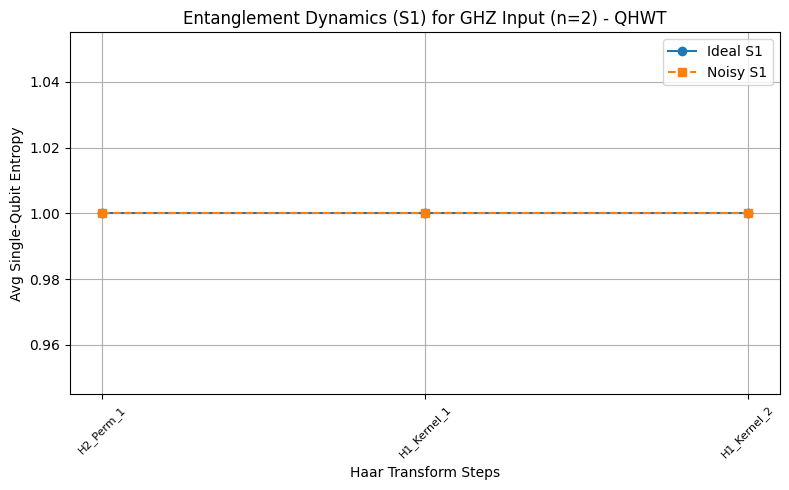

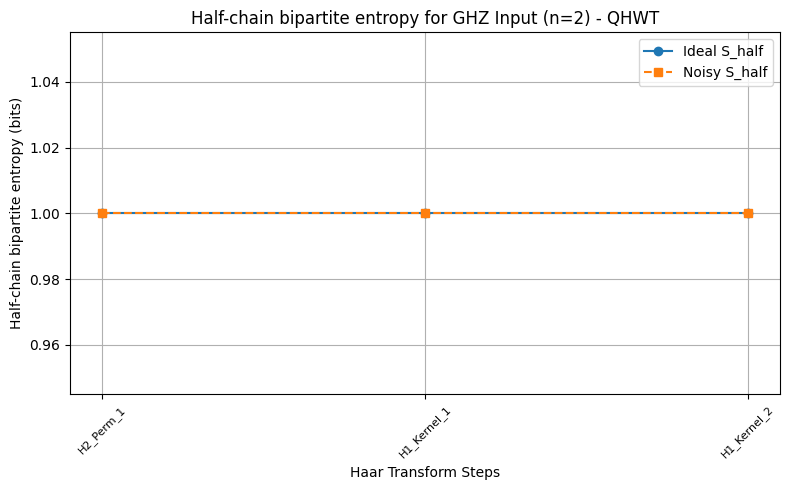

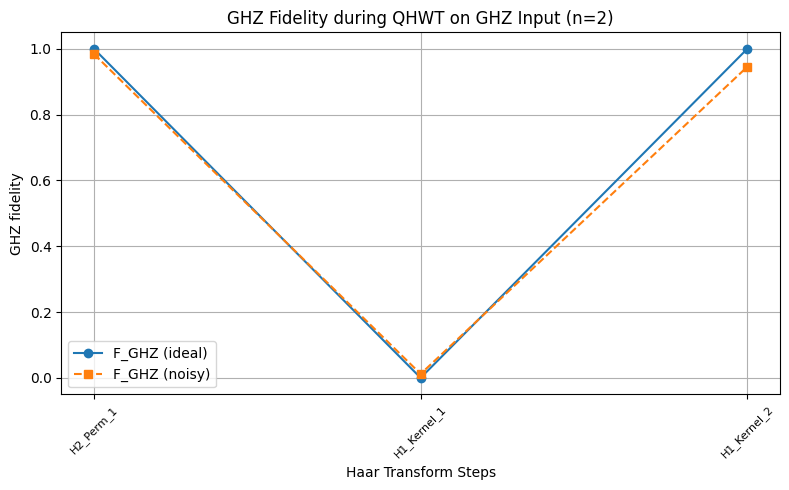

n=2: S1_final (ideal=1.0000, noisy=1.0000); S_half_final (ideal=1.0000, noisy=1.0000); F_GHZ_final (ideal=1.0000, noisy=0.9454)


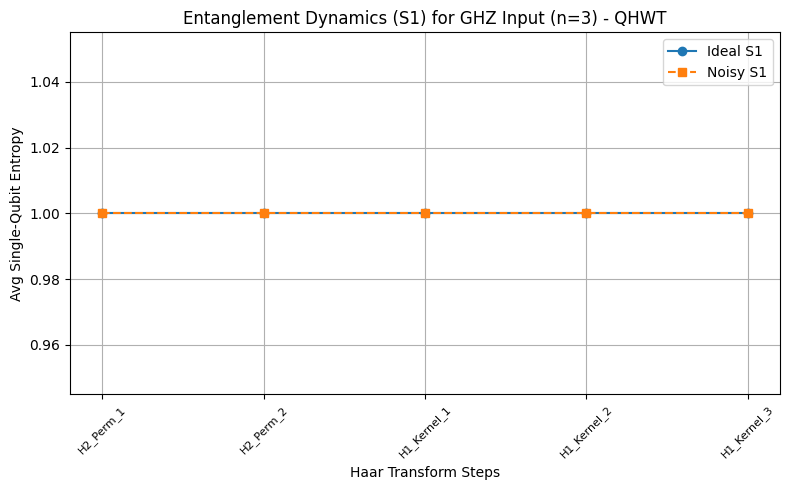

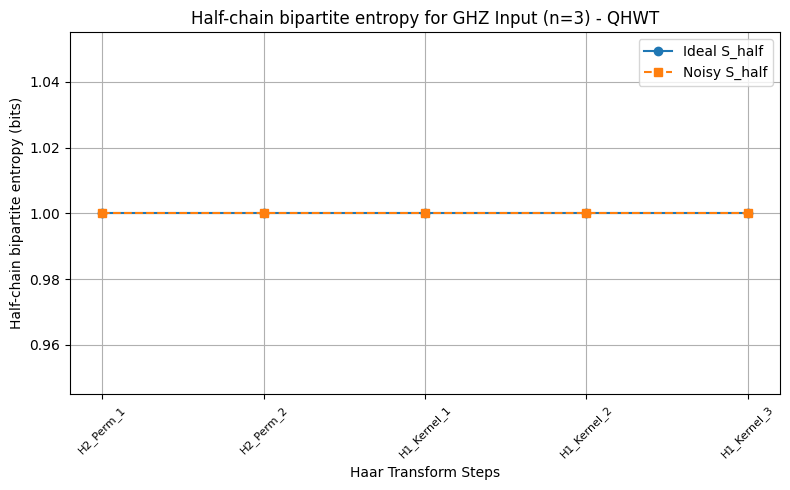

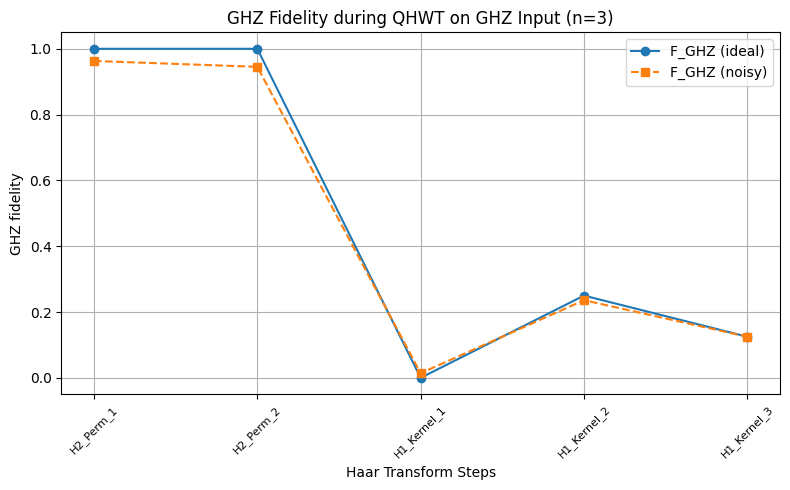

n=3: S1_final (ideal=1.0000, noisy=1.0000); S_half_final (ideal=1.0000, noisy=1.0000); F_GHZ_final (ideal=0.1250, noisy=0.1250)


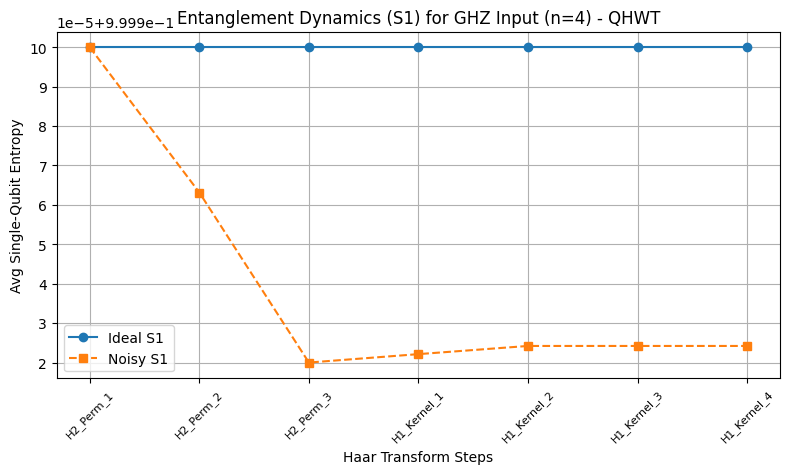

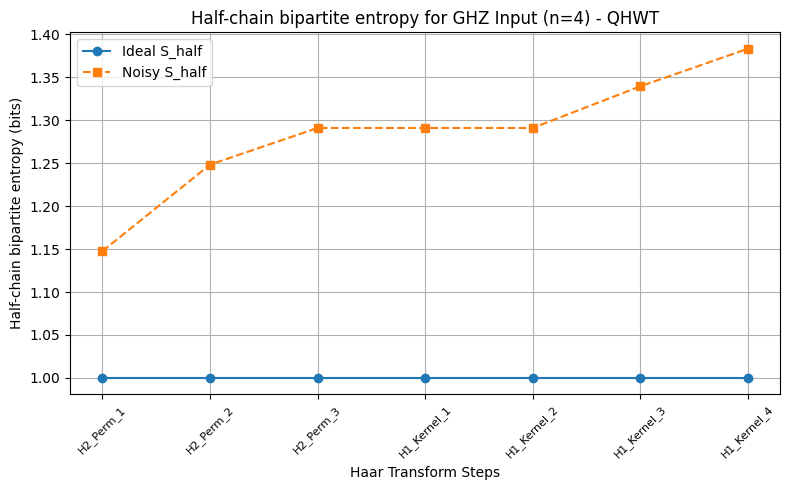

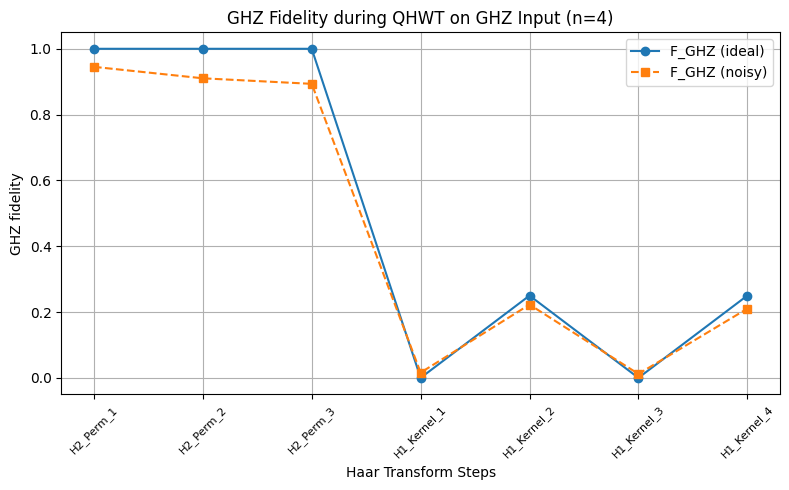

n=4: S1_final (ideal=1.0000, noisy=0.9999); S_half_final (ideal=1.0000, noisy=1.3833); F_GHZ_final (ideal=0.2500, noisy=0.2104)


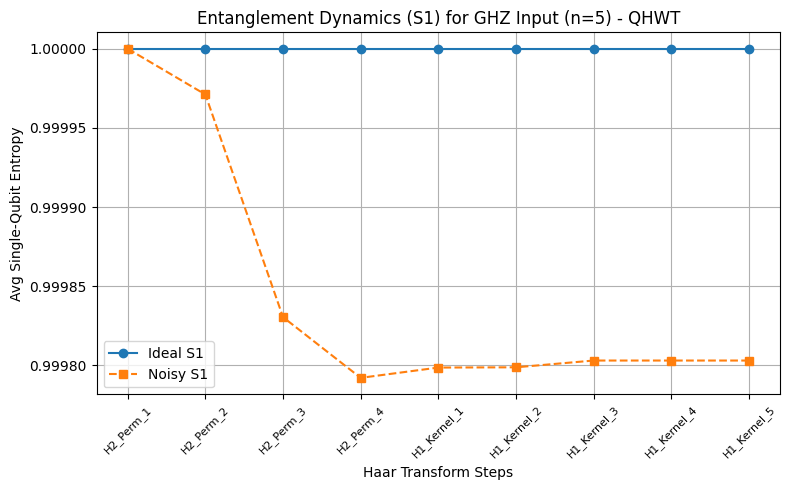

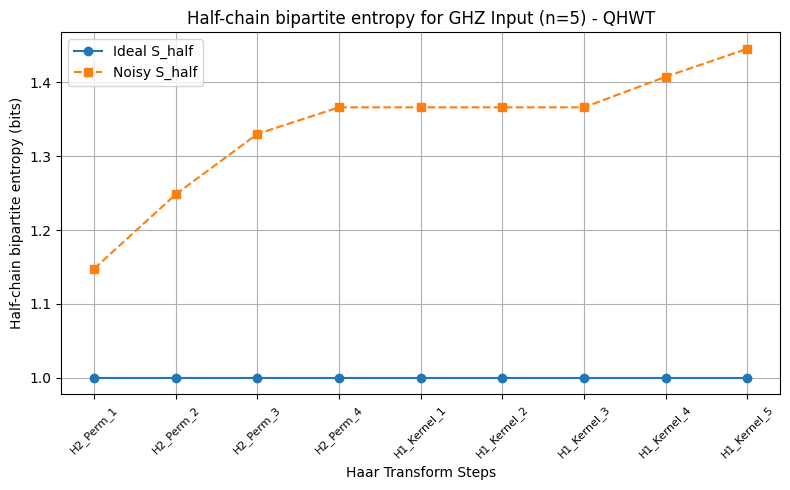

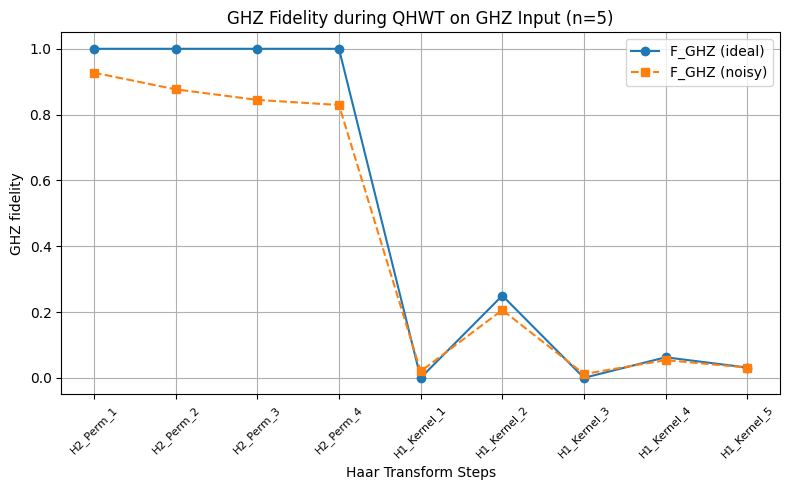

n=5: S1_final (ideal=1.0000, noisy=0.9998); S_half_final (ideal=1.0000, noisy=1.4453); F_GHZ_final (ideal=0.0312, noisy=0.0312)


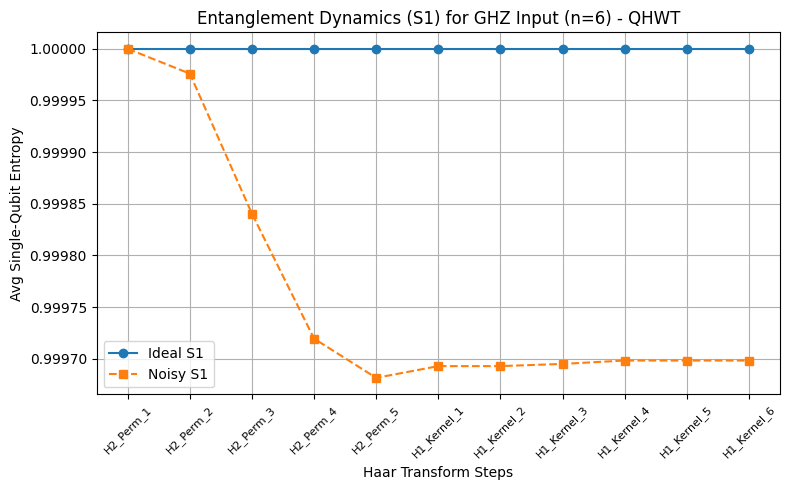

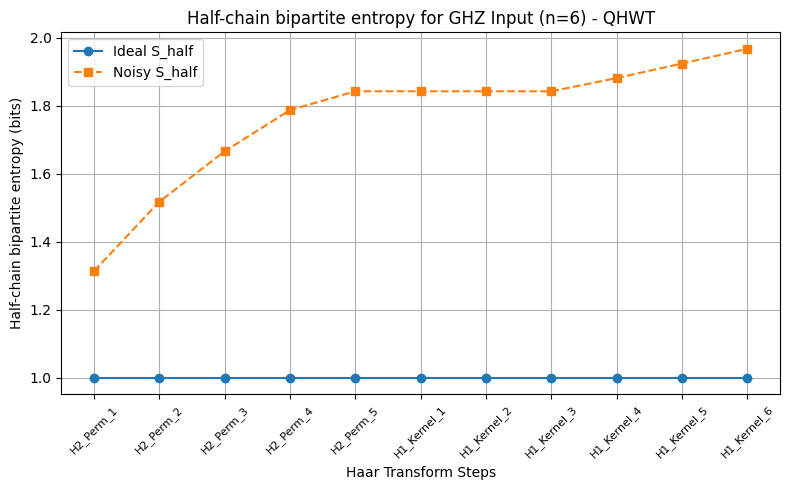

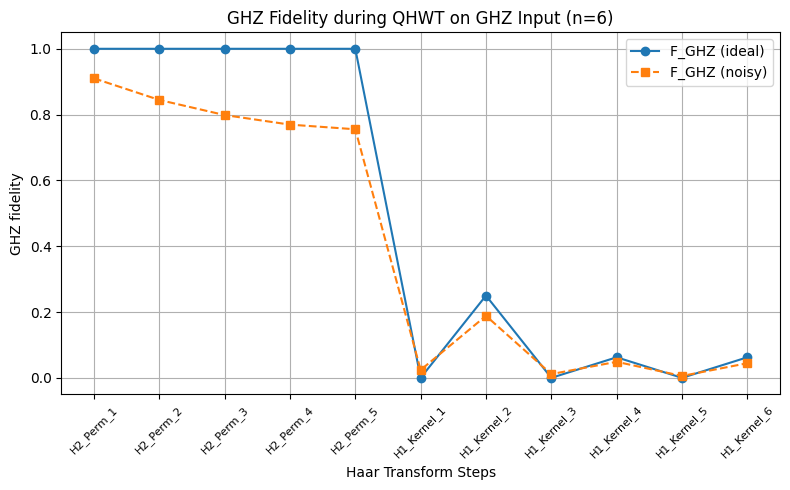

n=6: S1_final (ideal=1.0000, noisy=0.9997); S_half_final (ideal=1.0000, noisy=1.9669); F_GHZ_final (ideal=0.0625, noisy=0.0445)


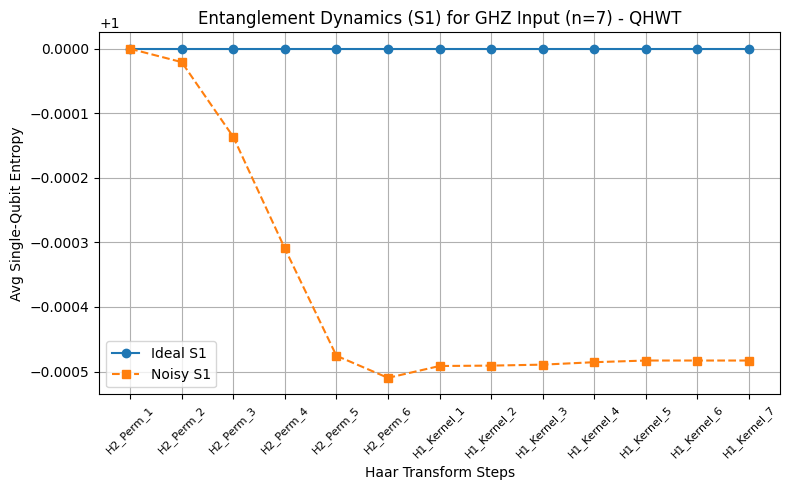

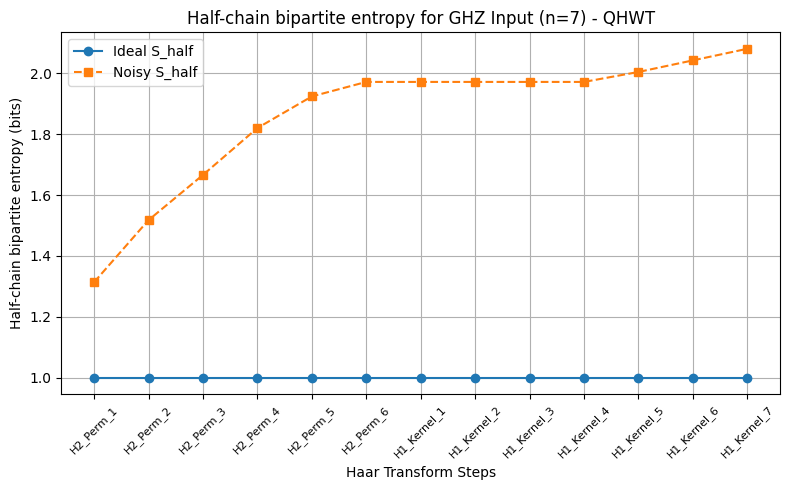

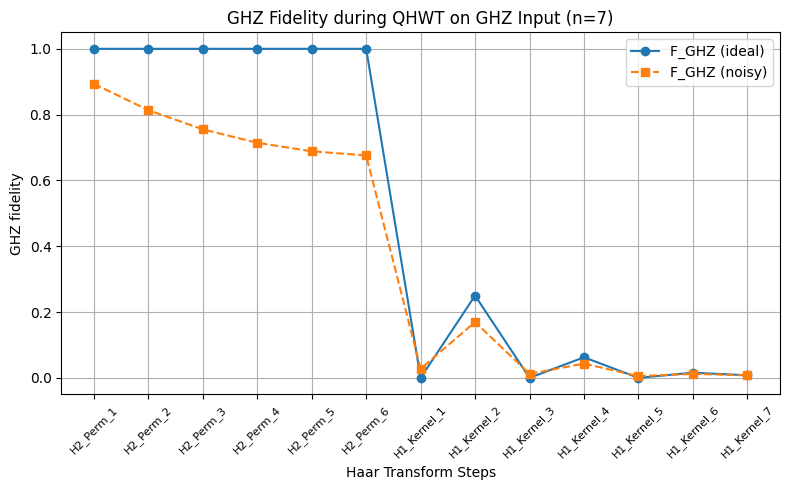

n=7: S1_final (ideal=1.0000, noisy=0.9995); S_half_final (ideal=1.0000, noisy=2.0799); F_GHZ_final (ideal=0.0078, noisy=0.0078)


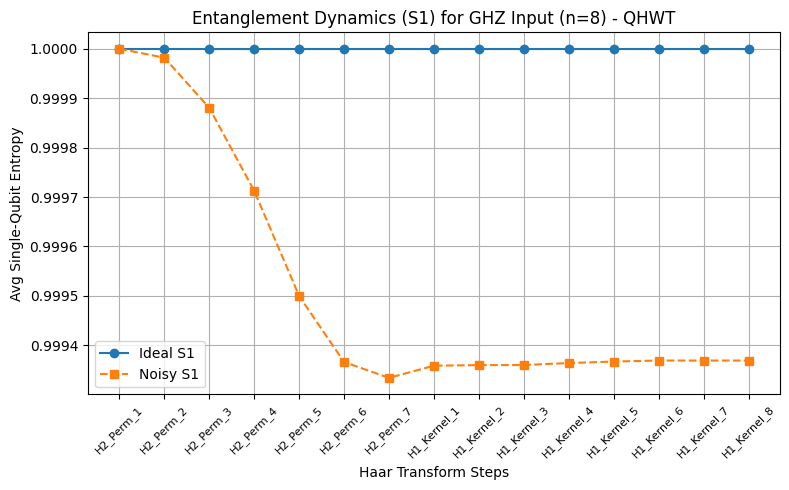

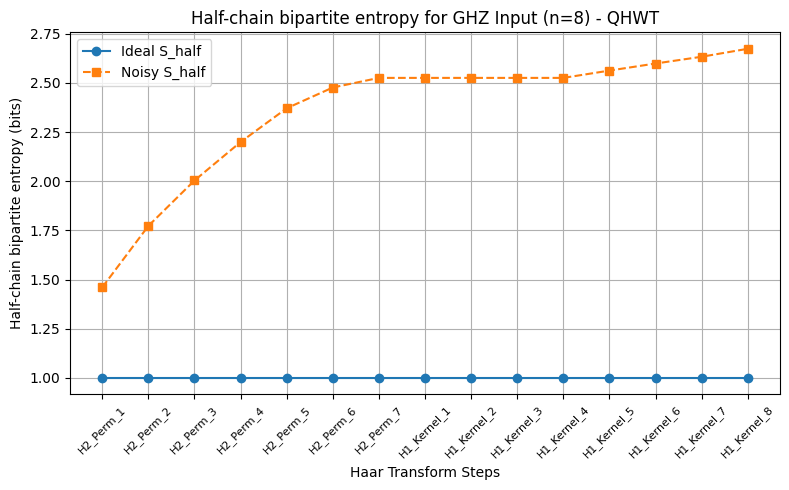

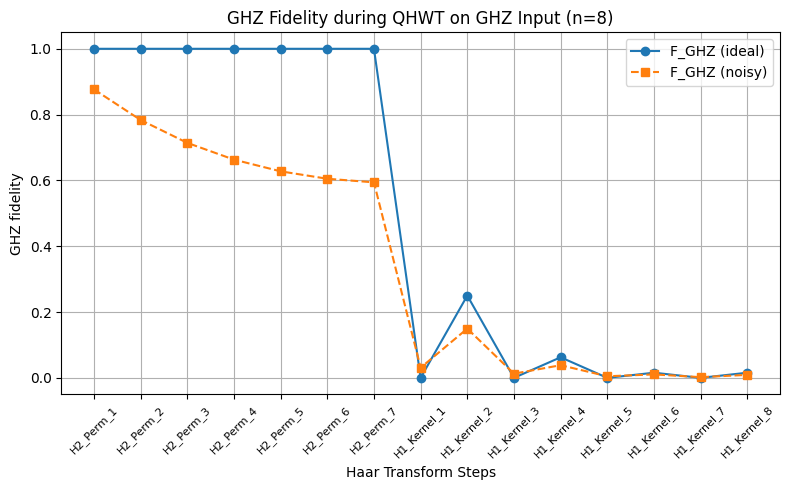

n=8: S1_final (ideal=1.0000, noisy=0.9994); S_half_final (ideal=1.0000, noisy=2.6740); F_GHZ_final (ideal=0.0156, noisy=0.0091)


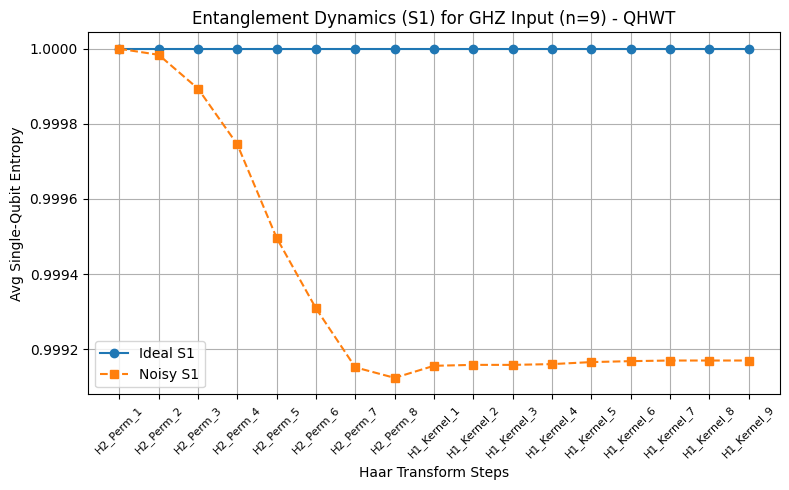

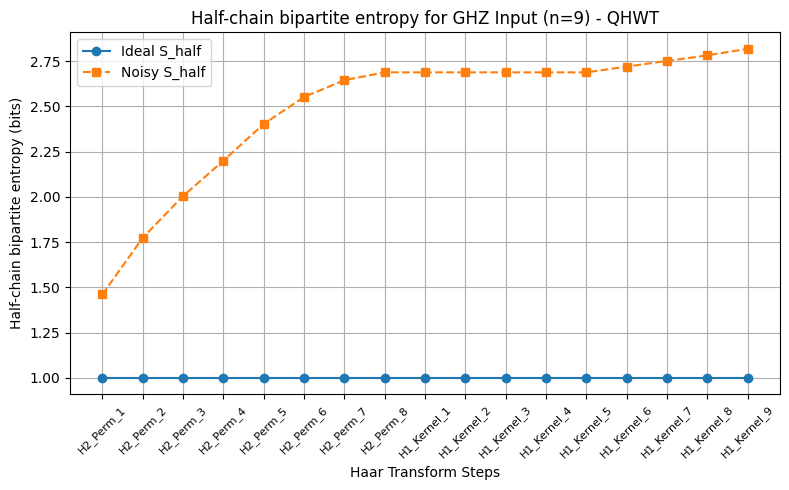

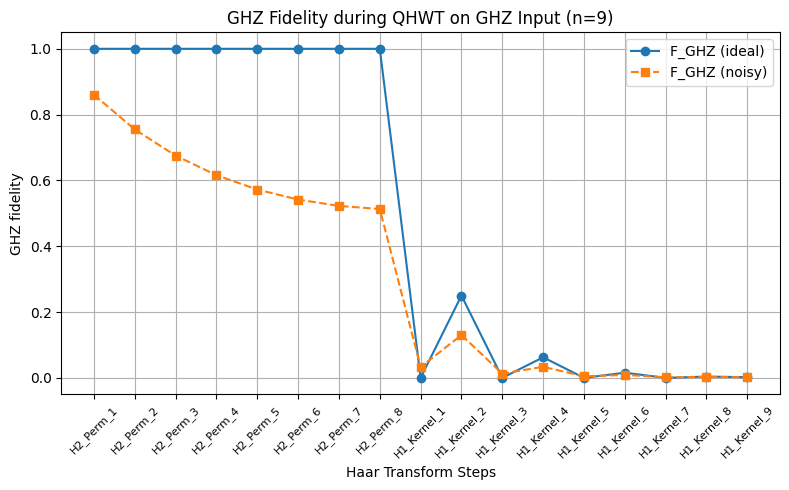

n=9: S1_final (ideal=1.0000, noisy=0.9992); S_half_final (ideal=1.0000, noisy=2.8185); F_GHZ_final (ideal=0.0020, noisy=0.0020)


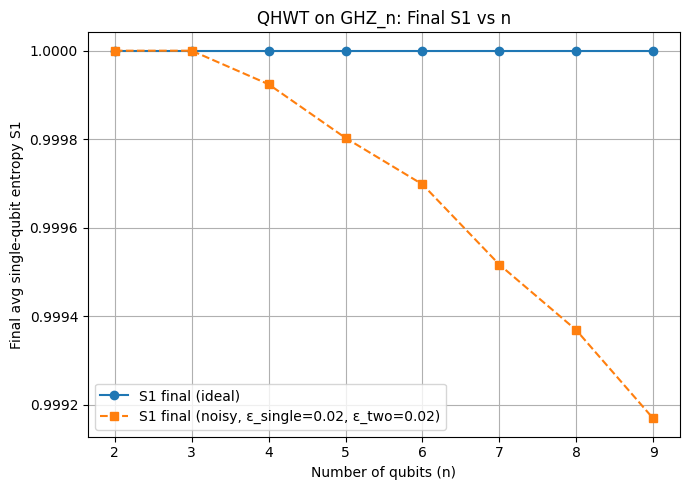

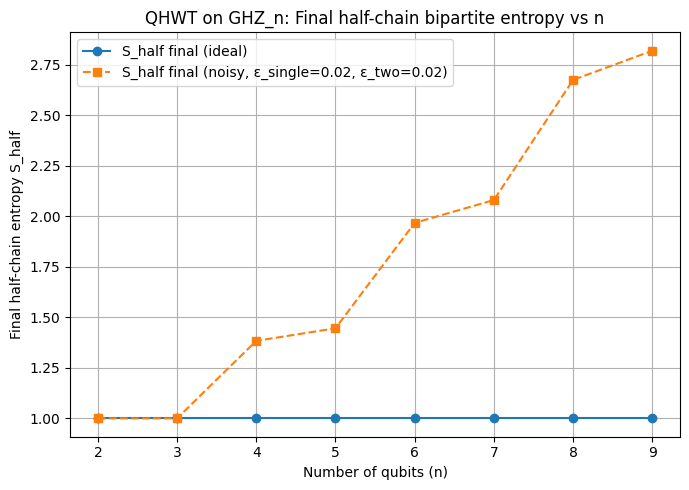

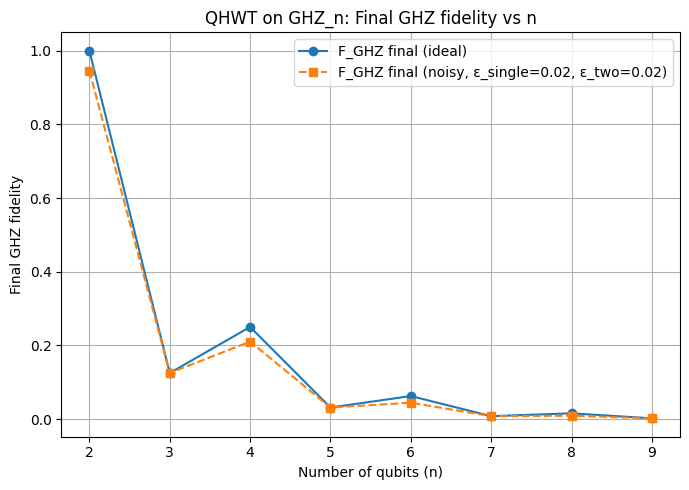

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import log2

# ----------------- helpers -----------------
def W_matrix():
    """2x2 Haar kernel (Hadamard)"""
    return np.array([[1,1],[1,-1]], dtype=complex)/np.sqrt(2)

def kron_list(mats):
    M = mats[0]
    for A in mats[1:]:
        M = np.kron(M, A)
    return M

def perfect_shuffle_perm(N):
    n = int(round(log2(N)))
    perm = np.zeros(N, dtype=int)
    for i in range(N):
        low = i & 1
        high = i >> 1
        perm[i] = (low << (n-1)) | high
    P = np.zeros((N,N), dtype=complex)
    for i,j in enumerate(perm):
        P[j,i] = 1.0
    return P

def block_diag(matrices):
    total = sum(m.shape[0] for m in matrices)
    B = np.zeros((total, total), dtype=complex)
    offset = 0
    for m in matrices:
        s = m.shape[0]
        B[offset:offset+s, offset:offset+s] = m
        offset += s
    return B

def partial_trace_single(rho, n, q):
    rho_tensor = rho.reshape([2]*(2*n))
    ket_order = [q] + [i for i in range(n) if i!=q]
    bra_order = [q+n] + [i+n for i in range(n) if i!=q]
    perm = ket_order + bra_order
    rho_perm = np.transpose(rho_tensor, perm)
    dim_rem = 2**(n-1)
    rho_reshaped = rho_perm.reshape((2, dim_rem, 2, dim_rem))
    reduced = np.trace(rho_reshaped, axis1=1, axis2=3)
    return reduced

def von_neumann_entropy(rho):
    rho = 0.5*(rho + rho.conj().T)
    vals = np.real_if_close(np.linalg.eigvalsh(rho))
    vals = np.clip(vals, 1e-14, 1)  # avoid log of 0 or negative rounding
    return -np.sum(vals * np.log2(vals))

# ---- general partial trace ----
def partial_trace(rho, keep, n):
    """
    Trace out all qubits except those in 'keep' (list of indices).
    """
    keep = sorted(keep)
    trace = [i for i in range(n) if i not in keep]

    dims = [2]*n
    rho_reshaped = rho.reshape(dims + dims)
    dims_per_block = n
    for t in sorted(trace, reverse=True):
        rho_reshaped = np.trace(rho_reshaped, axis1=t, axis2=t + dims_per_block)
        dims_per_block -= 1
    dim_keep = 2**len(keep)
    return rho_reshaped.reshape(dim_keep, dim_keep)

# ---- half-chain bipartite entropy ----
def bipartite_half_entropy(rho, n):
    """
    Bipartite entropy between first half (A) and second half (B).
    A = qubits [0 .. half-1].
    """
    half = n // 2
    if half == 0 or half == n:
        return 0.0
    keep_A = list(range(half))
    rho_A = partial_trace(rho, keep_A, n)
    return von_neumann_entropy(rho_A)

# ----------------- GHZ state + fidelity -----------------
def ghz_state(n):
    zero = np.array([1,0], dtype=complex)
    one  = np.array([0,1], dtype=complex)
    ket0, ket1 = zero, one
    for _ in range(n-1):
        ket0 = np.kron(ket0, zero)  # |0>^{⊗n}
        ket1 = np.kron(ket1, one)   # |1>^{⊗n}
    return (ket0 + ket1) / np.sqrt(2)

def ghz_fidelity(rho, n):
    g = ghz_state(n)
    return float(np.real_if_close(g.conj().T @ rho @ g))

# ----------------- noise operators -----------------
def make_single_qubit_kraus(eps):
    """Standard depolarizing channel Kraus set"""
    I = np.array([[1,0],[0,1]], dtype=complex)
    X = np.array([[0,1],[1,0]], dtype=complex)
    Y = np.array([[0,-1j],[1j,0]], dtype=complex)
    Z = np.array([[1,0],[0,-1]], dtype=complex)
    K0 = np.sqrt(1 - eps) * I
    K1 = np.sqrt(eps/3) * X
    K2 = np.sqrt(eps/3) * Y
    K3 = np.sqrt(eps/3) * Z
    return [K0, K1, K2, K3]

def apply_single_qubit_noise(rho, n, q, kraus_ops):
    new_rho = np.zeros_like(rho, dtype=complex)
    for K in kraus_ops:
        op_list = [np.eye(2, dtype=complex) for _ in range(n)]
        op_list[q] = K
        K_full = op_list[0]
        for op in op_list[1:]:
            K_full = np.kron(K_full, op)
        new_rho += K_full @ rho @ K_full.conj().T
    return 0.5 * (new_rho + new_rho.conj().T)

def apply_two_qubit_noise(rho, n, q1, q2, epsilon):
    I = np.array([[1,0],[0,1]], dtype=complex)
    X = np.array([[0,1],[1,0]], dtype=complex)
    Y = np.array([[0,-1j],[1j,0]], dtype=complex)
    Z = np.array([[1,0],[0,-1]], dtype=complex)
    paulis = [I, X, Y, Z]
    full_ops = []
    for P1 in paulis:
        for P2 in paulis:
            full = None
            for idx in range(n):
                if idx == q1:
                    op = P1
                elif idx == q2:
                    op = P2
                else:
                    op = np.eye(2, dtype=complex)
                full = op if full is None else np.kron(full, op)
            full_ops.append(full)
    dim_sub = 4
    num_non_id = dim_sub**2 - 1
    p = epsilon / num_non_id
    new_rho = np.zeros_like(rho, dtype=complex)
    for idx, P_full in enumerate(full_ops):
        if idx == 0:
            continue
        new_rho += p * (P_full @ rho @ P_full.conj().T)
    new_rho += (1 - epsilon) * rho
    return 0.5 * (new_rho + new_rho.conj().T)

# ----------------- build Haar transform -----------------
def build_H2_permutation_factors(n):
    N = 2**n
    factors, active_sizes = [], []
    # full-length shuffle
    factors.append(perfect_shuffle_perm(N))
    active_sizes.append(n)
    # nested shuffles
    for i in range(n-1, 1, -1):
        k = 2**i
        Pk = perfect_shuffle_perm(k)
        if N - k > 0:
            block = block_diag([Pk, np.eye(N-k, dtype=complex)])
        else:
            block = Pk
        factors.append(block)
        active_sizes.append(i)
    return factors, active_sizes

def build_H1_kernel_factors(n):
    N = 2**n
    W = W_matrix()
    factors = []
    for l in range(0, n):
        blocksize = 2**(l+1)
        num_blocks = 2**(n - (l+1))
        local = np.kron(W, np.eye(2**l, dtype=complex))
        blocks = [local for _ in range(num_blocks)]
        Op = block_diag(blocks)
        factors.append(Op)
    return factors

def assemble_Haar(n):
    H2_factors, active_sizes = build_H2_permutation_factors(n)
    H1_factors = build_H1_kernel_factors(n)
    return H2_factors, active_sizes, H1_factors

# ----------------- ideal QHWT -----------------
def entanglement_evolution_ideal(n):
    N = 2**n
    H2_factors, active_sizes, H1_factors = assemble_Haar(n)
    psi0 = ghz_state(n)
    rho = np.outer(psi0, psi0.conj())

    ent_history = []      # S1
    half_history = []     # S_half
    fid_history = []      # F_GHZ
    stage_labels = []

    for idx, P in enumerate(H2_factors, start=1):
        rho = P @ rho @ P.conj().T

        ent_single = [von_neumann_entropy(partial_trace_single(rho, n, q)) for q in range(n)]
        ent_history.append(np.mean(ent_single))

        S_half = bipartite_half_entropy(rho, n)
        half_history.append(S_half)

        F = ghz_fidelity(rho, n)
        fid_history.append(F)

        stage_labels.append(f"H2_Perm_{idx}")

    for idx, K in enumerate(H1_factors, start=1):
        rho = K @ rho @ K.conj().T

        ent_single = [von_neumann_entropy(partial_trace_single(rho, n, q)) for q in range(n)]
        ent_history.append(np.mean(ent_single))

        S_half = bipartite_half_entropy(rho, n)
        half_history.append(S_half)

        F = ghz_fidelity(rho, n)
        fid_history.append(F)

        stage_labels.append(f"H1_Kernel_{idx}")

    return stage_labels, ent_history, half_history, fid_history

# ----------------- noisy QHWT -----------------
def entanglement_evolution_noisy(n, eps_single=0.01, eps_two=0.01):
    N = 2**n
    H2_factors, active_sizes, H1_factors = assemble_Haar(n)
    psi0 = ghz_state(n)
    rho = np.outer(psi0, psi0.conj())

    ent_history = []      # S1
    half_history = []     # S_half
    fid_history = []      # F_GHZ
    stage_labels = []

    kraus_ops = make_single_qubit_kraus(eps_single)

    for idx, P in enumerate(H2_factors, start=1):
        rho = P @ rho @ P.conj().T
        active_i = active_sizes[idx-1]
        # apply two-qubit noise on active region
        for q in range(active_i-1, 0, -1):
            rho = apply_two_qubit_noise(rho, n, q, q-1, eps_two)

        ent_single = [von_neumann_entropy(partial_trace_single(rho, n, q)) for q in range(n)]
        ent_history.append(np.mean(ent_single))

        S_half = bipartite_half_entropy(rho, n)
        half_history.append(S_half)

        F = ghz_fidelity(rho, n)
        fid_history.append(F)

        stage_labels.append(f"H2_Perm_{idx}")

    for idx, K in enumerate(H1_factors, start=1):
        rho = K @ rho @ K.conj().T

        target_q = n - idx
        if 0 <= target_q < n:
            rho = apply_single_qubit_noise(rho, n, target_q, kraus_ops)

        ent_single = [von_neumann_entropy(partial_trace_single(rho, n, q)) for q in range(n)]
        ent_history.append(np.mean(ent_single))

        S_half = bipartite_half_entropy(rho, n)
        half_history.append(S_half)

        F = ghz_fidelity(rho, n)
        fid_history.append(F)

        stage_labels.append(f"H1_Kernel_{idx}")

    return stage_labels, ent_history, half_history, fid_history

# ----------------- per-n dynamics + scaling vs n -----------------

eps_single = 0.02
eps_two = 0.02

n_values = []
final_S1_ideal = []
final_S1_noisy = []
final_Shalf_ideal = []
final_Shalf_noisy = []
final_F_ideal = []
final_F_noisy = []

for n in range(2, 10):  # skip n=1 (GHZ_1 trivial)
    labels, ideal_ent, ideal_half, ideal_F = entanglement_evolution_ideal(n)
    _, noisy_ent, noisy_half, noisy_F = entanglement_evolution_noisy(
        n, eps_single=eps_single, eps_two=eps_two
    )

    # ---- per-step plots for each n ----
    # S1 plot
    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(ideal_ent)+1), ideal_ent, marker='o', label='Ideal S1')
    plt.plot(range(1, len(noisy_ent)+1), noisy_ent, marker='s', linestyle='--', label='Noisy S1')
    plt.xticks(range(1, len(labels)+1), labels, rotation=45, fontsize=8)
    plt.xlabel("Haar Transform Steps")
    plt.ylabel("Avg Single-Qubit Entropy")
    plt.title(f"Entanglement Dynamics (S1) for GHZ Input (n={n}) - QHWT")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Half-chain bipartite entropy
    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(ideal_half)+1), ideal_half, marker='o', label='Ideal S_half')
    plt.plot(range(1, len(noisy_half)+1), noisy_half, marker='s', linestyle='--', label='Noisy S_half')
    plt.xticks(range(1, len(labels)+1), labels, rotation=45, fontsize=8)
    plt.xlabel("Haar Transform Steps")
    plt.ylabel("Half-chain bipartite entropy (bits)")
    plt.title(f"Half-chain bipartite entropy for GHZ Input (n={n}) - QHWT")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # GHZ fidelity
    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(ideal_F)+1), ideal_F, marker='o', label='F_GHZ (ideal)')
    plt.plot(range(1, len(noisy_F)+1), noisy_F, marker='s', linestyle='--', label='F_GHZ (noisy)')
    plt.xticks(range(1, len(labels)+1), labels, rotation=45, fontsize=8)
    plt.xlabel("Haar Transform Steps")
    plt.ylabel("GHZ fidelity")
    plt.title(f"GHZ Fidelity during QHWT on GHZ Input (n={n})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ---- collect final values for scaling vs n ----
    n_values.append(n)
    final_S1_ideal.append(ideal_ent[-1])
    final_S1_noisy.append(noisy_ent[-1])
    final_Shalf_ideal.append(ideal_half[-1])
    final_Shalf_noisy.append(noisy_half[-1])
    final_F_ideal.append(ideal_F[-1])
    final_F_noisy.append(noisy_F[-1])

    print(
        f"n={n}: S1_final (ideal={ideal_ent[-1]:.4f}, noisy={noisy_ent[-1]:.4f}); "
        f"S_half_final (ideal={ideal_half[-1]:.4f}, noisy={noisy_half[-1]:.4f}); "
        f"F_GHZ_final (ideal={ideal_F[-1]:.4f}, noisy={noisy_F[-1]:.4f})"
    )

# ----------------- summary scaling plots -----------------

# 1) Final S1 vs n
plt.figure(figsize=(7,5))
plt.plot(n_values, final_S1_ideal, marker='o', label='S1 final (ideal)')
plt.plot(n_values, final_S1_noisy, marker='s', linestyle='--',
         label=f'S1 final (noisy, ε_single={eps_single}, ε_two={eps_two})')
plt.xlabel('Number of qubits (n)')
plt.ylabel('Final avg single-qubit entropy S1')
plt.title('QHWT on GHZ_n: Final S1 vs n')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 2) Final S_half vs n
plt.figure(figsize=(7,5))
plt.plot(n_values, final_Shalf_ideal, marker='o', label='S_half final (ideal)')
plt.plot(n_values, final_Shalf_noisy, marker='s', linestyle='--',
         label=f'S_half final (noisy, ε_single={eps_single}, ε_two={eps_two})')
plt.xlabel('Number of qubits (n)')
plt.ylabel('Final half-chain entropy S_half')
plt.title('QHWT on GHZ_n: Final half-chain bipartite entropy vs n')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 3) Final GHZ fidelity vs n
plt.figure(figsize=(7,5))
plt.plot(n_values, final_F_ideal, marker='o', label='F_GHZ final (ideal)')
plt.plot(n_values, final_F_noisy, marker='s', linestyle='--',
         label=f'F_GHZ final (noisy, ε_single={eps_single}, ε_two={eps_two})')
plt.xlabel('Number of qubits (n)')
plt.ylabel('Final GHZ fidelity')
plt.title('QHWT on GHZ_n: Final GHZ fidelity vs n')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


AQC analysis

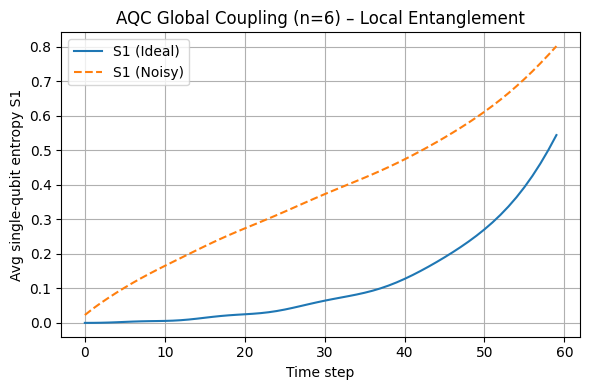

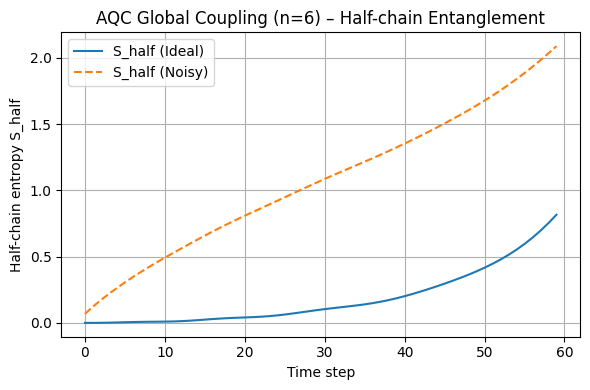

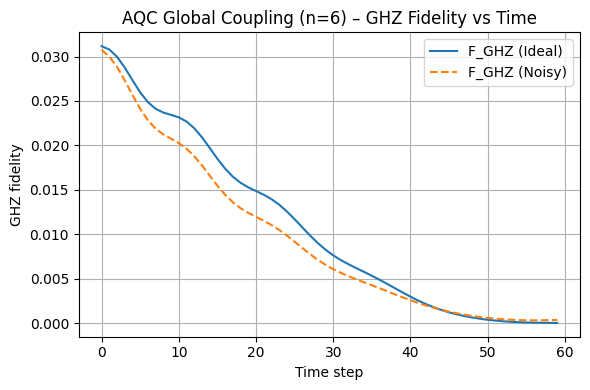

>>> Running AQC global-coupling for n=2
   Final S1: ideal=0.9996, noisy=0.9998; S_half: ideal=0.9996, noisy=0.9998; F_GHZ: ideal=0.0018, noisy=0.0502
>>> Running AQC global-coupling for n=3
   Final S1: ideal=0.6472, noisy=0.8610; S_half: ideal=0.6472, noisy=0.8610; F_GHZ: ideal=0.0023, noisy=0.0247
>>> Running AQC global-coupling for n=4
   Final S1: ideal=0.7787, noisy=0.9039; S_half: ideal=0.9822, noisy=1.5943; F_GHZ: ideal=0.0004, noisy=0.0053
>>> Running AQC global-coupling for n=5
   Final S1: ideal=0.6036, noisy=0.8388; S_half: ideal=0.8009, noisy=1.5312; F_GHZ: ideal=0.0001, noisy=0.0014
>>> Running AQC global-coupling for n=6
   Final S1: ideal=0.5440, noisy=0.8016; S_half: ideal=0.8162, noisy=2.0886; F_GHZ: ideal=0.0000, noisy=0.0003
>>> Running AQC global-coupling for n=7
   Final S1: ideal=0.4814, noisy=0.7689; S_half: ideal=0.7656, noisy=2.0546; F_GHZ: ideal=0.0000, noisy=0.0001
>>> Running AQC global-coupling for n=8
   Final S1: ideal=0.4354, noisy=0.7428; S_half: ideal

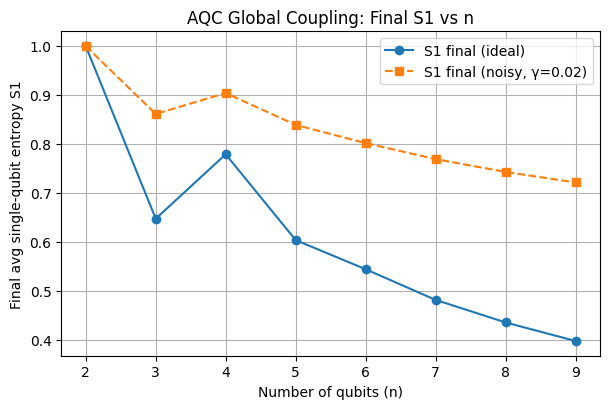

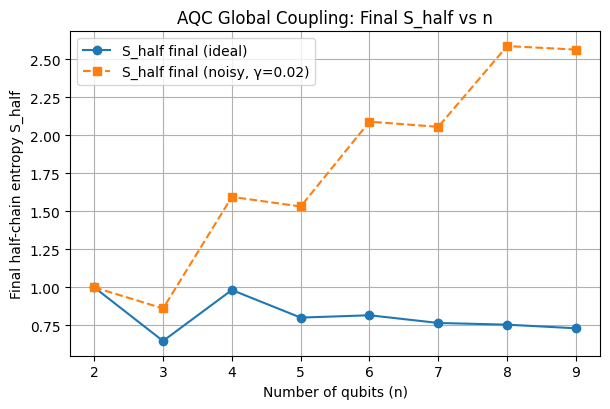

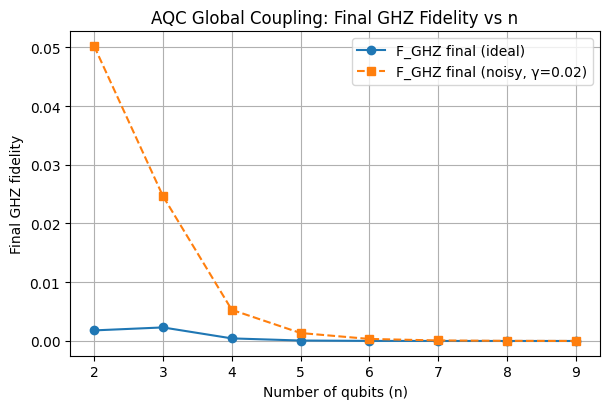

In [ ]:
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Pauli matrices
# ------------------------------------------------------------
I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def kron_n(ops):
    M = ops[0]
    for A in ops[1:]:
        M = np.kron(M, A)
    return M

def operator_on_qubit(op, q, n):
    """Embed single-qubit op on qubit q (0..n-1)."""
    ops = [I for _ in range(n)]
    ops[q] = op
    return kron_n(ops)

def partial_trace_single(rho, n, q):
    """Trace out all qubits except q: ρ -> ρ_q."""
    rho_tensor = rho.reshape([2]*(2*n))
    ket_order = [q] + [i for i in range(n) if i != q]
    bra_order = [q+n] + [i+n for i in range(n) if i != q]
    perm = ket_order + bra_order
    rho_perm = np.transpose(rho_tensor, perm)
    dim_rem = 2**(n-1)
    rho_reshaped = rho_perm.reshape((2, dim_rem, 2, dim_rem))
    reduced = np.trace(rho_reshaped, axis1=1, axis2=3)
    return reduced

def von_neumann_entropy(rho):
    rho = 0.5*(rho + rho.conj().T)
    vals = np.real_if_close(np.linalg.eigvalsh(rho))
    vals = np.clip(vals, 1e-14, 1)
    return float(-np.sum(vals * np.log2(vals)))

def apply_depolarizing_noise(rho, eps_step, q, n, Xq, Yq, Zq):
    """Single-qubit depolarizing noise on qubit q."""
    noisy = (1 - eps_step) * rho
    noisy += (eps_step / 3) * (Xq @ rho @ Xq.conj().T)
    noisy += (eps_step / 3) * (Yq @ rho @ Yq.conj().T)
    noisy += (eps_step / 3) * (Zq @ rho @ Zq.conj().T)
    noisy = 0.5 * (noisy + noisy.conj().T)
    tr = np.trace(noisy)
    if abs(tr - 1) > 1e-12:
        noisy /= tr
    return noisy

# ------------------------------------------------------------
# Bipartite half-chain entropy
# ------------------------------------------------------------
def bipartite_entropy(rho, n):
    """
    Entropy between first half (A) and second half (B).
    A = qubits [0 .. half-1].
    """
    half = n // 2
    if half == 0 or half == n:
        return 0.0
    dimA = 2**half
    dimB = 2**(n - half)
    rho_tensor = rho.reshape([dimA, dimB, dimA, dimB])
    rhoA = np.trace(rho_tensor, axis1=1, axis2=3)
    rhoA = 0.5*(rhoA + rhoA.conj().T)
    vals = np.real_if_close(np.linalg.eigvalsh(rhoA))
    vals = np.clip(vals, 1e-14, 1)
    S = float(-np.sum(vals * np.log2(vals)))
    return S

# ------------------------------------------------------------
# GHZ state and fidelity
# ------------------------------------------------------------
def ghz_state(n):
    """|GHZ_n> = (|0...0> + |1...1>)/sqrt(2)."""
    dim = 2**n
    v = np.zeros(dim, dtype=complex)
    v[0]  = 1/np.sqrt(2)
    v[-1] = 1/np.sqrt(2)
    return v

def ghz_fidelity(rho, n):
    """F = <GHZ_n| ρ |GHZ_n>."""
    g = ghz_state(n)
    return float(np.real(g.conj().T @ (rho @ g)))

# ------------------------------------------------------------
# AQC simulation with global cost term + S1, S_half, GHZ fidelity
# ------------------------------------------------------------
def run_aqc_global(n_qubits=6, T=10.0, steps=60, gamma=0.02, J=1.0):
    """
    Returns:
      ent_ideal[steps]     : average single-qubit entropy S1 (ideal)
      ent_noisy[steps]     : S1 (noisy)
      bip_ideal[steps]     : half-chain entropy S_half (ideal)
      bip_noisy[steps]     : S_half (noisy)
      F_ideal[steps]       : GHZ fidelity (ideal)
      F_noisy[steps]       : GHZ fidelity (noisy)
    """
    dt = T / steps
    eps_step = 1.0 - np.exp(-gamma * dt)
    dim = 2**n_qubits

    # Precompute single-qubit lifts
    X_list = [operator_on_qubit(X, q, n_qubits) for q in range(n_qubits)]
    Y_list = [operator_on_qubit(Y, q, n_qubits) for q in range(n_qubits)]
    Z_list = [operator_on_qubit(Z, q, n_qubits) for q in range(n_qubits)]

    # Hamiltonians
    H_start = -sum(X_list)  # driver term
    H_problem = np.zeros((dim, dim), dtype=complex)

    # Global all-to-all ZZ coupling
    for i in range(n_qubits):
        for j in range(i+1, n_qubits):
            H_problem += (J / (n_qubits - 1)) * (Z_list[i] @ Z_list[j])

    # Initial |+>^n state
    plus = (1/np.sqrt(2)) * np.array([1, 1], dtype=complex)
    psi0 = plus
    for _ in range(n_qubits - 1):
        psi0 = np.kron(psi0, plus)
    rho_ideal = np.outer(psi0, psi0.conjugate())
    rho_noisy = rho_ideal.copy()

    ent_ideal, ent_noisy = [], []
    bip_ideal, bip_noisy = [], []
    F_ideal,  F_noisy  = [], []

    # --------------------------------------------------------
    # Main evolution loop
    # --------------------------------------------------------
    for step in range(steps):
        s = (step + 0.5) / steps
        H_t = (1 - s) * H_start + s * H_problem
        U_t = expm(-1j * H_t * dt)

        # Ideal evolution
        rho_ideal = U_t @ rho_ideal @ U_t.conj().T

        # Noisy evolution
        rho_noisy = U_t @ rho_noisy @ U_t.conj().T
        for q in range(n_qubits):
            rho_noisy = apply_depolarizing_noise(
                rho_noisy, eps_step, q, n_qubits,
                X_list[q], Y_list[q], Z_list[q]
            )

        # Average single-qubit entropies S1
        e_i = np.mean([
            von_neumann_entropy(partial_trace_single(rho_ideal, n_qubits, q))
            for q in range(n_qubits)
        ])
        e_n = np.mean([
            von_neumann_entropy(partial_trace_single(rho_noisy, n_qubits, q))
            for q in range(n_qubits)
        ])
        ent_ideal.append(e_i)
        ent_noisy.append(e_n)

        # Half-chain entropies S_half
        S_bip_i = bipartite_entropy(rho_ideal, n_qubits)
        S_bip_n = bipartite_entropy(rho_noisy, n_qubits)
        bip_ideal.append(S_bip_i)
        bip_noisy.append(S_bip_n)

        # GHZ fidelities
        F_i = ghz_fidelity(rho_ideal, n_qubits)
        F_n = ghz_fidelity(rho_noisy, n_qubits)
        F_ideal.append(F_i)
        F_noisy.append(F_n)

        # (optional debug)
        # print(f"Step {step+1}/{steps}, s={s:.3f}, "
        #       f"S1_i={e_i:.3f}, S1_n={e_n:.3f}, "
        #       f"S_half_i={S_bip_i:.3f}, S_half_n={S_bip_n:.3f}, "
        #       f"F_i={F_i:.3f}, F_n={F_n:.3f}")

    return (np.array(ent_ideal), np.array(ent_noisy),
            np.array(bip_ideal), np.array(bip_noisy),
            np.array(F_ideal),  np.array(F_noisy))

# ------------------------------------------------------------
# 1) Example: full time series for a fixed n
# ------------------------------------------------------------
n_qubits = 6
T = 10.0
steps = 60
gamma = 0.02
J = 1.0

(ent_i, ent_n,
 bip_i,  bip_n,
 F_i,    F_n) = run_aqc_global(
    n_qubits=n_qubits, T=T, steps=steps, gamma=gamma, J=J
)

# Plot S1
plt.figure(figsize=(6,4))
plt.plot(ent_i, label='S1 (Ideal)')
plt.plot(ent_n, label='S1 (Noisy)', linestyle='--')
plt.xlabel('Time step')
plt.ylabel('Avg single-qubit entropy S1')
plt.title(f'AQC Global Coupling (n={n_qubits}) – Local Entanglement')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()

# Plot S_half
plt.figure(figsize=(6,4))
plt.plot(bip_i, label='S_half (Ideal)')
plt.plot(bip_n, label='S_half (Noisy)', linestyle='--')
plt.xlabel('Time step')
plt.ylabel('Half-chain entropy S_half')
plt.title(f'AQC Global Coupling (n={n_qubits}) – Half-chain Entanglement')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()

# Plot GHZ fidelity
plt.figure(figsize=(6,4))
plt.plot(F_i, label='F_GHZ (Ideal)')
plt.plot(F_n, label='F_GHZ (Noisy)', linestyle='--')
plt.xlabel('Time step')
plt.ylabel('GHZ fidelity')
plt.title(f'AQC Global Coupling (n={n_qubits}) – GHZ Fidelity vs Time')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2) Scaling of final S1, S_half, F_GHZ vs n
# ------------------------------------------------------------
n_min, n_max = 2, 9
n_values = []
S1_final_ideal = []
S1_final_noisy = []
Shalf_final_ideal = []
Shalf_final_noisy = []
F_final_ideal = []
F_final_noisy = []

for n in range(n_min, n_max + 1):
    print(f">>> Running AQC global-coupling for n={n}")
    ent_i, ent_n, bip_i, bip_n, F_i, F_n = run_aqc_global(
        n_qubits=n, T=T, steps=steps, gamma=gamma, J=J
    )

    n_values.append(n)
    S1_final_ideal.append(float(ent_i[-1]))
    S1_final_noisy.append(float(ent_n[-1]))
    Shalf_final_ideal.append(float(bip_i[-1]))
    Shalf_final_noisy.append(float(bip_n[-1]))
    F_final_ideal.append(float(F_i[-1]))
    F_final_noisy.append(float(F_n[-1]))

    print(f"   Final S1: ideal={ent_i[-1]:.4f}, noisy={ent_n[-1]:.4f}; "
          f"S_half: ideal={bip_i[-1]:.4f}, noisy={bip_n[-1]:.4f}; "
          f"F_GHZ: ideal={F_i[-1]:.4f}, noisy={F_n[-1]:.4f}")

# --- Plot scaling: S1_final vs n ---
plt.figure(figsize=(6.2, 4.2))
plt.plot(n_values, S1_final_ideal, marker='o', label='S1 final (ideal)')
plt.plot(n_values, S1_final_noisy, marker='s', linestyle='--',
         label=f'S1 final (noisy, γ={gamma})')
plt.xlabel('Number of qubits (n)')
plt.ylabel('Final avg single-qubit entropy S1')
plt.title('AQC Global Coupling: Final S1 vs n')
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()

# --- Plot scaling: S_half_final vs n ---
plt.figure(figsize=(6.2, 4.2))
plt.plot(n_values, Shalf_final_ideal, marker='o', label='S_half final (ideal)')
plt.plot(n_values, Shalf_final_noisy, marker='s', linestyle='--',
         label=f'S_half final (noisy, γ={gamma})')
plt.xlabel('Number of qubits (n)')
plt.ylabel('Final half-chain entropy S_half')
plt.title('AQC Global Coupling: Final S_half vs n')
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()

# --- Plot scaling: F_GHZ_final vs n ---
plt.figure(figsize=(6.2, 4.2))
plt.plot(n_values, F_final_ideal, marker='o', label='F_GHZ final (ideal)')
plt.plot(n_values, F_final_noisy, marker='s', linestyle='--',
         label=f'F_GHZ final (noisy, γ={gamma})')
plt.xlabel('Number of qubits (n)')
plt.ylabel('Final GHZ fidelity')
plt.title('AQC Global Coupling: Final GHZ Fidelity vs n')
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()


MBQC analysis

--- Starting Scan (Noise eps=0.1) ---
N=2 | Fid(Id/No): 1.0000/0.9333 | S1(Id/No): 1.0000/1.0000 | SAB(Id/No): 1.0000/1.0000
N=3 | Fid(Id/No): 1.0000/0.9333 | S1(Id/No): 1.0000/1.0000 | SAB(Id/No): 1.0000/1.0000
N=4 | Fid(Id/No): 1.0000/0.9333 | S1(Id/No): 1.0000/1.0000 | SAB(Id/No): 1.0000/1.0000
N=5 | Fid(Id/No): 1.0000/0.9333 | S1(Id/No): 1.0000/1.0000 | SAB(Id/No): 1.0000/1.0000
N=6 | Fid(Id/No): 1.0000/0.9333 | S1(Id/No): 1.0000/1.0000 | SAB(Id/No): 1.0000/1.0000
N=7 | Fid(Id/No): 1.0000/0.9333 | S1(Id/No): 1.0000/1.0000 | SAB(Id/No): 1.0000/1.0000
N=8 | Fid(Id/No): 1.0000/0.9333 | S1(Id/No): 1.0000/1.0000 | SAB(Id/No): 1.0000/1.0000
N=9 | Fid(Id/No): 1.0000/0.9333 | S1(Id/No): 1.0000/1.0000 | SAB(Id/No): 1.0000/1.0000


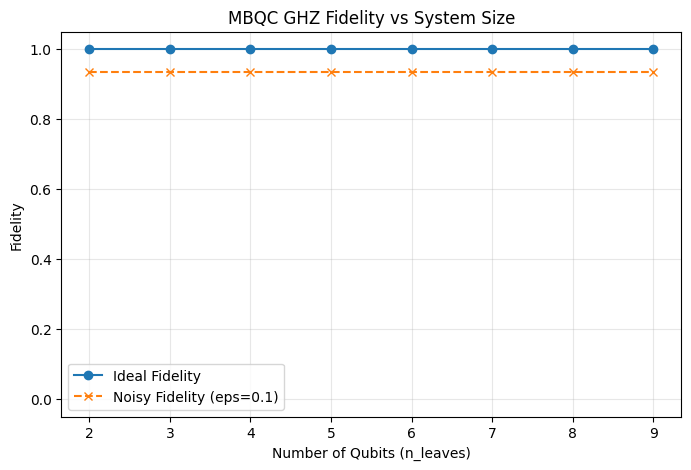

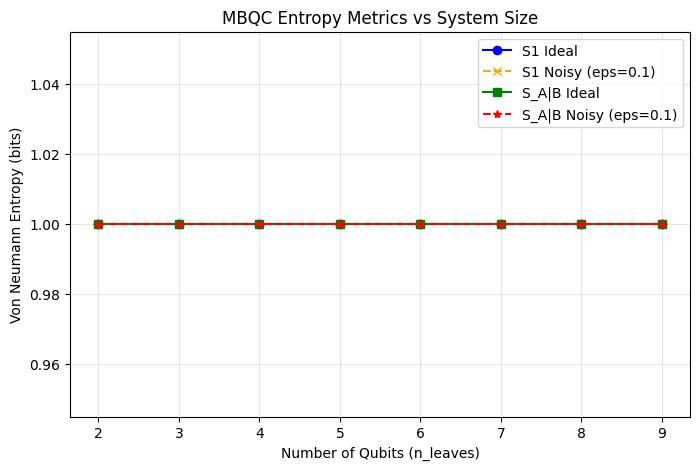

In [ ]:
import numpy as np
from numpy.linalg import eigh
import matplotlib.pyplot as plt

# ===============================
# 1. Basic single-qubit operators
# ===============================

I = np.array([[1, 0], [0, 1]], dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

# Hadamard
H = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)

# |+>, |->
plus  = (1/np.sqrt(2)) * np.array([1, 1], dtype=complex)
minus = (1/np.sqrt(2)) * np.array([1, -1], dtype=complex)

P_plus  = np.outer(plus,  plus.conj())
P_minus = np.outer(minus, minus.conj())


# ===============================
# 2. General helpers
# ===============================

def kron_list(mats):
    """Kronecker product over a list of matrices in order."""
    out = mats[0]
    for m in mats[1:]:
        out = np.kron(out, m)
    return out


def operator_on_qubit(op, target, n_qubits):
    """Embed 2x2 operator 'op' on 'target' qubit."""
    mats = []
    for i in range(n_qubits):
        mats.append(op if i == target else I)
    return kron_list(mats)


def partial_trace(rho, keep, n_qubits):
    """Trace out all qubits except those in 'keep'."""
    keep = sorted(keep)
    trace = [i for i in range(n_qubits) if i not in keep]

    dims = [2] * n_qubits
    rho_reshaped = rho.reshape(dims + dims)

    dims_per_block = n_qubits
    for t in sorted(trace, reverse=True):
        rho_reshaped = np.trace(rho_reshaped, axis1=t, axis2=t + dims_per_block)
        dims_per_block -= 1

    dim_keep = 2 ** len(keep)
    return rho_reshaped.reshape(dim_keep, dim_keep)


def von_neumann_entropy(rho, tol=1e-12):
    """S(rho) = -Tr(rho log_2 rho)."""
    vals, _ = eigh(rho)
    vals = np.real(vals)
    vals = vals[vals > tol]
    if len(vals) == 0:
        return 0.0
    return float(-np.sum(vals * np.log2(vals)))


def average_single_qubit_entropy(rho, n_qubits):
    """Calculate average S1 over all qubits."""
    entropies = []
    for q in range(n_qubits):
        rho_q = partial_trace(rho, [q], n_qubits)
        entropies.append(von_neumann_entropy(rho_q))
    return float(np.mean(entropies))


def bipartite_half_entropy(rho, n_qubits):
    """Calculate S_A|B (Half-cut entropy)."""
    nA = n_qubits // 2
    keep_A = list(range(nA))
    rho_A = partial_trace(rho, keep_A, n_qubits)
    return von_neumann_entropy(rho_A)


def ghz_state(n_qubits):
    """|GHZ_n> = (|0...0> + |1...1>)/sqrt(2)."""
    dim = 2 ** n_qubits
    v = np.zeros(dim, dtype=complex)
    v[0]  = 1/np.sqrt(2)
    v[-1] = 1/np.sqrt(2)
    return v


def ghz_fidelity(rho, n_qubits):
    """F = <GHZ_n| rho |GHZ_n>."""
    ghz = ghz_state(n_qubits)
    return float(np.real(ghz.conj().T @ (rho @ ghz)))


# ===============================
# 3. MBQC Logic (Corrected Endianness)
# ===============================

def plus_state_density(n_qubits):
    psi = plus
    for _ in range(n_qubits - 1):
        psi = np.kron(psi, plus)
    rho = np.outer(psi, psi.conj())
    return rho


def apply_cz_star(rho, hub, leaves, n_qubits):
    """
    Apply CZ star graph.
    FIX: Uses (n_qubits - 1 - k) shifting to match Kronecker MSB ordering.
    """
    dim = 2 ** n_qubits
    # Precompute diagonal phase vector
    diags = np.ones(dim, dtype=complex)

    for i in range(dim):
        # Extract bits (MSB 0)
        hub_bit = (i >> (n_qubits - 1 - hub)) & 1
        if hub_bit == 1:
            for leaf in leaves:
                leaf_bit = (i >> (n_qubits - 1 - leaf)) & 1
                if leaf_bit == 1:
                    diags[i] *= -1.0

    rho = (diags[:, None] * rho) * diags[None, :]
    return rho


def depolarize_single_qubit_on(rho, target, n_qubits, eps):
    if eps == 0.0:
        return rho
    X_full = operator_on_qubit(X, target, n_qubits)
    Y_full = operator_on_qubit(Y, target, n_qubits)
    Z_full = operator_on_qubit(Z, target, n_qubits)
    term = (X_full @ rho @ X_full.conj().T +
            Y_full @ rho @ Y_full.conj().T +
            Z_full @ rho @ Z_full.conj().T)
    return (1 - eps)*rho + (eps/3.0)*term


def mbqc_star_ghz_leaves_density(n_leaves, eps,
                                 hub_index=0,
                                 correct_leaf_global=1):
    """
    Corrected MBQC GHZ protocol.
    - Correct Bit-Indexing
    - Correct Z-gate Correction logic
    """
    n_qubits = n_leaves + 1
    leaves_global = [i for i in range(n_qubits) if i != hub_index]

    # 1) Initial |+>
    rho = plus_state_density(n_qubits)

    # 2) Entangle
    rho = apply_cz_star(rho, hub_index, leaves_global, n_qubits)

    # 3) Noise
    rho = depolarize_single_qubit_on(rho, hub_index, n_qubits, eps)

    # 4) Measure Hub
    Pp_full = operator_on_qubit(P_plus,  hub_index, n_qubits)
    Pm_full = operator_on_qubit(P_minus, hub_index, n_qubits)

    rho0_unnorm = Pp_full @ rho @ Pp_full.conj().T
    p0 = np.real(np.trace(rho0_unnorm))

    rho1_unnorm = Pm_full @ rho @ Pm_full.conj().T
    p1 = np.real(np.trace(rho1_unnorm))

    # 5) Trace out hub
    if p0 > 1e-15:
        rho0_leaves = partial_trace(rho0_unnorm / p0, leaves_global, n_qubits)
    else:
        rho0_leaves = np.zeros((2**n_leaves, 2**n_leaves), dtype=complex)

    if p1 > 1e-15:
        rho1_leaves = partial_trace(rho1_unnorm / p1, leaves_global, n_qubits)
    else:
        rho1_leaves = np.zeros((2**n_leaves, 2**n_leaves), dtype=complex)

    # 6) Rotate ALL leaves to Z-basis
    H_layer = kron_list([H] * n_leaves)
    rho0_rot = H_layer @ rho0_leaves @ H_layer.conj().T
    rho1_rot = H_layer @ rho1_leaves @ H_layer.conj().T

    # 7) Apply CORRECTION (Z-GATE)
    target_leaf_local = leaves_global.index(correct_leaf_global)
    Z_corr = operator_on_qubit(Z, target_leaf_local, n_leaves)
    rho1_corrected = Z_corr @ rho1_rot @ Z_corr.conj().T

    # 8) Combine
    rho_final = p0 * rho0_rot + p1 * rho1_corrected

    if np.trace(rho_final) > 0:
        rho_final = rho_final / np.trace(rho_final)

    return rho_final


# ===============================
# 4. Combined Scan & Plotting
# ===============================

def mbqc_combined_scan(max_n_leaves=6, eps=0.05):
    # n_leaves to scan
    n_values = list(range(2, max_n_leaves + 1))

    # Storage lists
    S1_ideal, S1_noisy = [], []
    SAB_ideal, SAB_noisy = [], []
    F_ideal, F_noisy = [], []

    print(f"--- Starting Scan (Noise eps={eps}) ---")
    for n in n_values:
        # --- IDEAL CASE ---
        rho_ideal = mbqc_star_ghz_leaves_density(n, 0.0)

        f_id = ghz_fidelity(rho_ideal, n)
        s1_id = average_single_qubit_entropy(rho_ideal, n)
        sab_id = bipartite_half_entropy(rho_ideal, n)

        F_ideal.append(f_id)
        S1_ideal.append(s1_id)
        SAB_ideal.append(sab_id)

        # --- NOISY CASE ---
        rho_noisy = mbqc_star_ghz_leaves_density(n, eps)

        f_no = ghz_fidelity(rho_noisy, n)
        s1_no = average_single_qubit_entropy(rho_noisy, n)
        sab_no = bipartite_half_entropy(rho_noisy, n)

        F_noisy.append(f_no)
        S1_noisy.append(s1_no)
        SAB_noisy.append(sab_no)

        print(f"N={n} | Fid(Id/No): {f_id:.4f}/{f_no:.4f} | "
              f"S1(Id/No): {s1_id:.4f}/{s1_no:.4f} | "
              f"SAB(Id/No): {sab_id:.4f}/{sab_no:.4f}")

    # --- PLOT 1: FIDELITY ---
    plt.figure(figsize=(8, 5))
    plt.plot(n_values, F_ideal, 'o-', label='Ideal Fidelity')
    plt.plot(n_values, F_noisy, 'x--', label=f'Noisy Fidelity (eps={eps})')
    plt.ylim(-0.05, 1.05)
    plt.xlabel('Number of Qubits (n_leaves)')
    plt.ylabel('Fidelity')
    plt.title('MBQC GHZ Fidelity vs System Size')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- PLOT 2: ENTROPY ---
    plt.figure(figsize=(8, 5))
    # S1 plots
    plt.plot(n_values, S1_ideal, 'o-', color='blue', label='S1 Ideal')
    plt.plot(n_values, S1_noisy, 'x--', color='orange', label=f'S1 Noisy (eps={eps})')

    # SAB plots (Half-cut)
    plt.plot(n_values, SAB_ideal, 's-', color='green', label='S_A|B Ideal')
    plt.plot(n_values, SAB_noisy, '*--', color='red', label=f'S_A|B Noisy (eps={eps})')

    plt.xlabel('Number of Qubits (n_leaves)')
    plt.ylabel('Von Neumann Entropy (bits)')
    plt.title('MBQC Entropy Metrics vs System Size')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    # Run scan up to N=6 (computational limit for standard laptop is usually N=10-12)
    # Setting eps=0.1 to make the noise effects clearly visible
    mbqc_combined_scan(max_n_leaves=9, eps=0.1)

QCA analysis


In [ ]:
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt

# ============================================
# 1. Basic matrices & helpers
# ============================================

I2 = np.eye(2, dtype=complex)
X  = np.array([[0, 1],[1, 0]], dtype=complex)
Y  = np.array([[0,-1j],[1j, 0]], dtype=complex)
Z  = np.array([[1, 0],[0,-1]], dtype=complex)

def kron_list(mats):
    M = mats[0]
    for A in mats[1:]:
        M = np.kron(M, A)
    return M

def operator_on_qubit(op, q, n):
    ops = [I2 for _ in range(n)]
    ops[q] = op
    return kron_list(ops)

# ============================================
# 2. Partial trace + entropies (compatible with other models)
# ============================================

def partial_trace_general(rho, keep, n_qubits):
    """
    Trace out all qubits except those in 'keep' and
    return reduced density matrix on keep.
    """
    keep = sorted(keep)
    trace = [i for i in range(n_qubits) if i not in keep]

    dims = [2]*n_qubits
    rho_reshaped = rho.reshape(dims + dims)  # (ket dims | bra dims)
    dims_per_block = n_qubits

    for t in sorted(trace, reverse=True):
        rho_reshaped = np.trace(rho_reshaped, axis1=t, axis2=t + dims_per_block)
        dims_per_block -= 1

    dim_keep = 2**len(keep)
    return rho_reshaped.reshape(dim_keep, dim_keep)

def partial_trace_single(rho, n_qubits, q):
    return partial_trace_general(rho, [q], n_qubits)

def von_neumann_entropy(rho, tol=1e-14):
    """Von Neumann entropy in bits."""
    rho = 0.5*(rho + rho.conj().T)
    vals = np.real_if_close(np.linalg.eigvalsh(rho))
    vals = np.clip(vals, 0.0, 1.0)
    vals = vals[vals > tol]
    if vals.size == 0:
        return 0.0
    return float(-np.sum(vals * np.log2(vals)))

def average_single_qubit_entropy(rho, n_qubits):
    ent = []
    for q in range(n_qubits):
        rho_q = partial_trace_single(rho, n_qubits, q)
        ent.append(von_neumann_entropy(rho_q))
    return float(np.mean(ent)), np.array(ent)

def bipartite_entropy(rho, n_qubits):
    """
    Half-chain entropy S(A) where A = first floor(n/2) qubits.
    """
    if n_qubits <= 1:
        return 0.0
    half = n_qubits//2
    dimA, dimB = 2**half, 2**(n_qubits-half)
    rho_tensor = rho.reshape(dimA, dimB, dimA, dimB)
    rhoA = np.trace(rho_tensor, axis1=1, axis2=3)
    rhoA = 0.5*(rhoA + rhoA.conj().T)
    vals = np.real_if_close(np.linalg.eigvalsh(rhoA))
    vals = np.clip(vals, 0.0, 1.0)
    vals = vals[vals > 1e-14]
    if vals.size == 0:
        return 0.0
    return float(-np.sum(vals * np.log2(vals)))

def ghz_state(n_qubits):
    """|GHZ_n> = (|0...0> + |1...1>)/sqrt(2)."""
    dim = 2**n_qubits
    v = np.zeros(dim, dtype=complex)
    v[0]  = 1/np.sqrt(2)
    v[-1] = 1/np.sqrt(2)
    return v

def ghz_fidelity(rho, n_qubits):
    g = ghz_state(n_qubits)
    return float(np.real_if_close(g.conj().T @ rho @ g))

def block_entropy_r3(rho, n_qubits, r=3):
    """
    Average entropy of contiguous blocks of size r (the QCA rule's scale).
    """
    if n_qubits < r:
        return 0.0, np.array([])
    S_list = []
    for start in range(0, n_qubits-r+1):
        block = list(range(start, start+r))
        rho_block = partial_trace_general(rho, block, n_qubits)
        S_list.append(von_neumann_entropy(rho_block))
    return float(np.mean(S_list)), np.array(S_list)

# ============================================
# 3. Local TFIM block (r = 3) and brickwork pattern
# ============================================

def tfim_block_hamiltonian(J=1.0, h=0.5):
    """
    3-qubit TFIM block:
      H_block = -J (Z0 Z1 + Z1 Z2) - h (X0 + X1 + X2)
    """
    Z0Z1 = np.kron(np.kron(Z, Z), I2)
    Z1Z2 = np.kron(np.kron(I2, Z), Z)
    X0   = np.kron(np.kron(X, I2), I2)
    X1   = np.kron(np.kron(I2, X), I2)
    X2   = np.kron(np.kron(I2, I2), X)
    H_block = -J*(Z0Z1 + Z1Z2) - h*(X0 + X1 + X2)
    return H_block

def embed_block_unitary(U_block, start, n_qubits, r=3):
    assert 0 <= start <= n_qubits-r
    left  = [I2]*start
    right = [I2]*(n_qubits-(start+r))
    return kron_list(left + [U_block] + right)

def qca_even_block_starts(n_qubits, r=3):
    """
    Even layer: blocks start at 0, r, 2r, ...
    """
    return list(range(0, max(0, n_qubits-r+1), r))

def qca_odd_block_starts(n_qubits, r=3):
    """
    Odd layer: blocks shifted by r//2, e.g. 1, 4, 7,... for r=3.
    """
    first = r//2
    if n_qubits < first + r:
        return [first] if n_qubits >= first + r else []
    return list(range(first, n_qubits-r+1, r))

# ============================================
# 4. Single-qubit depolarizing noise (global)
# ============================================

def apply_depolarizing_single(rho, eps, Xq, Yq, Zq):
    """
    Single-qubit depolarizing channel on one lifted Pauli site.
    """
    if eps <= 0:
        return rho
    noisy = (1-eps)*rho
    noisy += (eps/3)*(Xq @ rho @ Xq.conj().T)
    noisy += (eps/3)*(Yq @ rho @ Yq.conj().T)
    noisy += (eps/3)*(Zq @ rho @ Zq.conj().T)
    noisy = 0.5*(noisy + noisy.conj().T)
    tr = np.trace(noisy)
    if abs(tr-1) > 1e-12 and abs(tr) > 0:
        noisy /= tr
    return noisy

# ============================================
# 5. QCA evolution starting from GHZ (ideal + noisy)
# ============================================

def run_qca_ghz(
    n_qubits,
    J=1.0,
    h=0.5,
    dt=0.1,
    num_steps=50,
    gamma=0.02
):
    """
    QCA with 3-qubit TFIM rule, brickwork pattern, starting from |GHZ_n>.

    Returns time series for:
      - S1_ideal, S1_noisy     (avg single-qubit entropy)
      - Shalf_ideal, Shalf_noisy (half-chain entropy)
      - Sblock_ideal, Sblock_noisy (avg block entropy, r=3)
      - F_ideal, F_noisy       (fidelity to GHZ)
    """
    dim = 2**n_qubits

    # local block unitary
    H_block = tfim_block_hamiltonian(J=J, h=h)
    U_block = expm(-1j*H_block*dt)

    even_starts = qca_even_block_starts(n_qubits, r=3)
    odd_starts  = qca_odd_block_starts(n_qubits, r=3)

    # initial GHZ
    g = ghz_state(n_qubits)
    rho_ideal = np.outer(g, g.conj())
    rho_noisy = rho_ideal.copy()

    # per-step depolarizing strength (like AQC)
    eps_step = 1.0 - np.exp(-gamma*dt) if gamma > 0 else 0.0
    X_list = [operator_on_qubit(X, q, n_qubits) for q in range(n_qubits)]
    Y_list = [operator_on_qubit(Y, q, n_qubits) for q in range(n_qubits)]
    Z_list = [operator_on_qubit(Z, q, n_qubits) for q in range(n_qubits)]

    times = []
    S1_i, S1_n = [], []
    Sh_i, Sh_n = [], []
    Sb_i, Sb_n = [], []
    F_i,  F_n  = [], []

    # ----- t = 0 -----
    t = 0.0
    times.append(t)
    S1_ideal, _ = average_single_qubit_entropy(rho_ideal, n_qubits)
    S1_noisy, _ = average_single_qubit_entropy(rho_noisy, n_qubits)
    Sh_ideal = bipartite_entropy(rho_ideal, n_qubits)
    Sh_noisy = bipartite_entropy(rho_noisy, n_qubits)
    Sb_ideal, _ = block_entropy_r3(rho_ideal, n_qubits, r=3)
    Sb_noisy, _ = block_entropy_r3(rho_noisy, n_qubits, r=3)
    Fi = ghz_fidelity(rho_ideal, n_qubits)
    Fn = ghz_fidelity(rho_noisy, n_qubits)

    S1_i.append(S1_ideal); S1_n.append(S1_noisy)
    Sh_i.append(Sh_ideal); Sh_n.append(Sh_noisy)
    Sb_i.append(Sb_ideal); Sb_n.append(Sb_noisy)
    F_i.append(Fi);        F_n.append(Fn)

    # ----- main evolution -----
    for step in range(1, num_steps+1):
        # even layer
        for start in even_starts:
            U_full = embed_block_unitary(U_block, start, n_qubits, r=3)
            rho_ideal = U_full @ rho_ideal @ U_full.conj().T
            rho_noisy = U_full @ rho_noisy @ U_full.conj().T
        # odd layer
        for start in odd_starts:
            U_full = embed_block_unitary(U_block, start, n_qubits, r=3)
            rho_ideal = U_full @ rho_ideal @ U_full.conj().T
            rho_noisy = U_full @ rho_noisy @ U_full.conj().T

        # noise on noisy copy
        if eps_step > 0:
            for q in range(n_qubits):
                rho_noisy = apply_depolarizing_single(
                    rho_noisy, eps_step, X_list[q], Y_list[q], Z_list[q]
                )

        # record
        t = step*dt
        times.append(t)
        S1_ideal, _ = average_single_qubit_entropy(rho_ideal, n_qubits)
        S1_noisy, _ = average_single_qubit_entropy(rho_noisy, n_qubits)
        Sh_ideal = bipartite_entropy(rho_ideal, n_qubits)
        Sh_noisy = bipartite_entropy(rho_noisy, n_qubits)
        Sb_ideal, _ = block_entropy_r3(rho_ideal, n_qubits, r=3)
        Sb_noisy, _ = block_entropy_r3(rho_noisy, n_qubits, r=3)
        Fi = ghz_fidelity(rho_ideal, n_qubits)
        Fn = ghz_fidelity(rho_noisy, n_qubits)

        S1_i.append(S1_ideal); S1_n.append(S1_noisy)
        Sh_i.append(Sh_ideal); Sh_n.append(Sh_noisy)
        Sb_i.append(Sb_ideal); Sb_n.append(Sb_noisy)
        F_i.append(Fi);        F_n.append(Fn)

    return {
        "t": np.array(times),
        "S1_ideal":   np.array(S1_i),
        "S1_noisy":   np.array(S1_n),
        "Shalf_ideal":np.array(Sh_i),
        "Shalf_noisy":np.array(Sh_n),
        "Sblock_ideal":np.array(Sb_i),
        "Sblock_noisy":np.array(Sb_n),
        "F_ideal":    np.array(F_i),
        "F_noisy":    np.array(F_n),
    }


In [ ]:
def qca_scaling_vs_n(
    n_min=2,
    n_max=8,
    J=1.0,
    h=0.5,
    dt=0.1,
    num_steps=50,
    gamma=0.02
):
    """
    Run QCA–GHZ for n = n_min..n_max, return final S1, S_half and F_GHZ
    for both ideal and noisy trajectories.
    """
    ns = list(range(n_min, n_max+1))
    final_S1_i, final_S1_n = [], []
    final_Sh_i, final_Sh_n = [], []
    final_F_i,  final_F_n  = [], []

    for n in ns:
        traj = run_qca_ghz(
            n_qubits=n,
            J=J, h=h,
            dt=dt, num_steps=num_steps,
            gamma=gamma
        )
        final_S1_i.append(traj["S1_ideal"][-1])
        final_S1_n.append(traj["S1_noisy"][-1])
        final_Sh_i.append(traj["Shalf_ideal"][-1])
        final_Sh_n.append(traj["Shalf_noisy"][-1])
        final_F_i.append(traj["F_ideal"][-1])
        final_F_n.append(traj["F_noisy"][-1])

    return {
        "n": np.array(ns),
        "S1_ideal":   np.array(final_S1_i),
        "S1_noisy":   np.array(final_S1_n),
        "Shalf_ideal":np.array(final_Sh_i),
        "Shalf_noisy":np.array(final_Sh_n),
        "F_ideal":    np.array(final_F_i),
        "F_noisy":    np.array(final_F_n),
    }


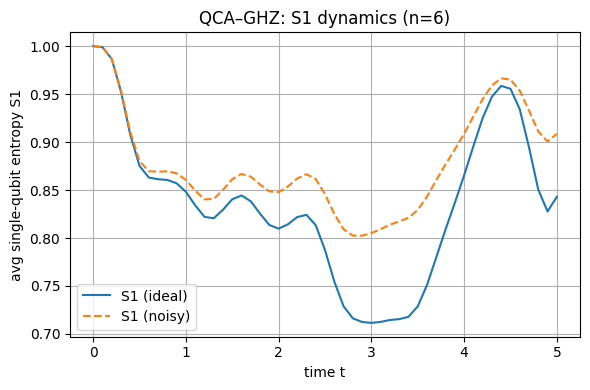

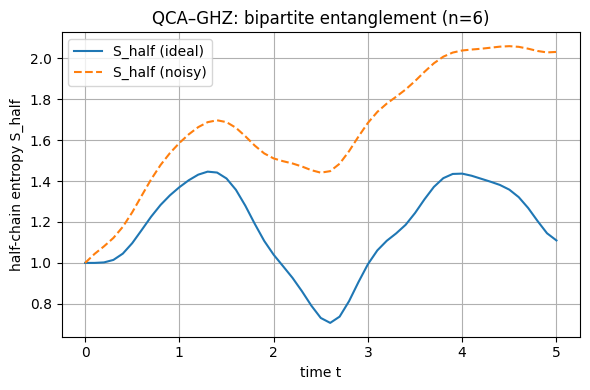

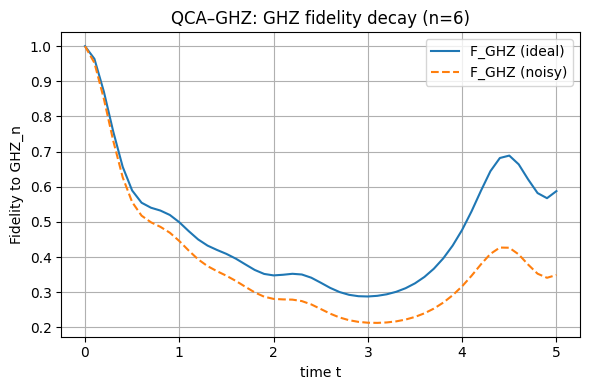

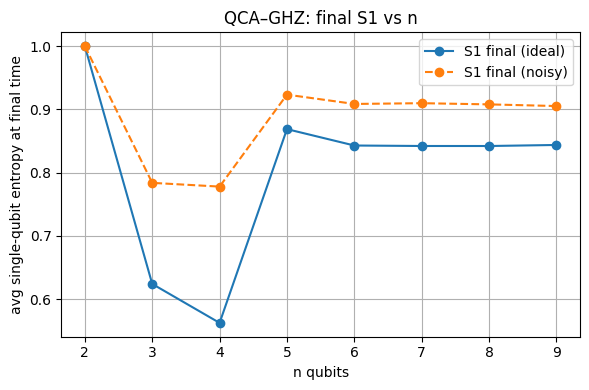

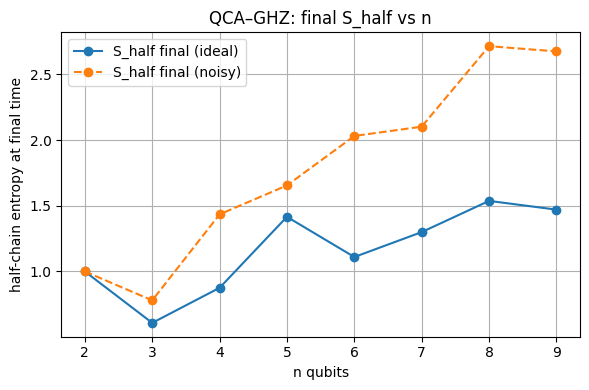

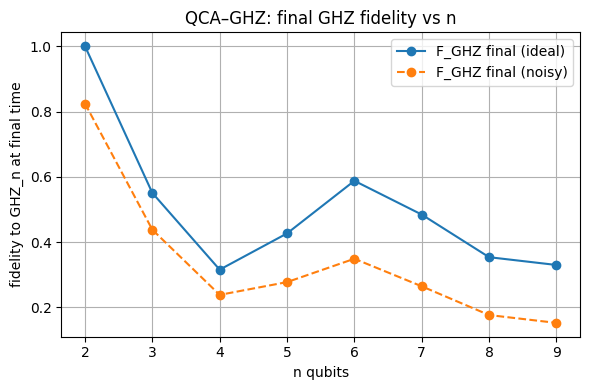

In [ ]:
if __name__ == "__main__":
    # ---------- time-dynamics at fixed n ----------
    n_demo   = 6
    dt       = 0.1
    steps    = 50
    gamma    = 0.02  # tune like in AQC

    traj = run_qca_ghz(
        n_qubits=n_demo,
        J=1.0, h=0.5,
        dt=dt, num_steps=steps,
        gamma=gamma
    )

    t = traj["t"]

    # S1 vs time
    plt.figure(figsize=(6,4))
    plt.plot(t, traj["S1_ideal"], label="S1 (ideal)")
    plt.plot(t, traj["S1_noisy"], label="S1 (noisy)", linestyle="--")
    plt.xlabel("time t")
    plt.ylabel("avg single-qubit entropy S1")
    plt.title(f"QCA–GHZ: S1 dynamics (n={n_demo})")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.show()

    # S_half vs time
    plt.figure(figsize=(6,4))
    plt.plot(t, traj["Shalf_ideal"], label="S_half (ideal)")
    plt.plot(t, traj["Shalf_noisy"], label="S_half (noisy)", linestyle="--")
    plt.xlabel("time t")
    plt.ylabel("half-chain entropy S_half")
    plt.title(f"QCA–GHZ: bipartite entanglement (n={n_demo})")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.show()

    # GHZ fidelity vs time
    plt.figure(figsize=(6,4))
    plt.plot(t, traj["F_ideal"], label="F_GHZ (ideal)")
    plt.plot(t, traj["F_noisy"], label="F_GHZ (noisy)", linestyle="--")
    plt.xlabel("time t")
    plt.ylabel("Fidelity to GHZ_n")
    plt.title(f"QCA–GHZ: GHZ fidelity decay (n={n_demo})")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.show()

    # ---------- scaling vs n ----------
    scaling = qca_scaling_vs_n(
        n_min=2, n_max=9,
        J=1.0, h=0.5,
        dt=dt, num_steps=steps,
        gamma=gamma
    )

    ns = scaling["n"]

    plt.figure(figsize=(6,4))
    plt.plot(ns, scaling["S1_ideal"],  "-o", label="S1 final (ideal)")
    plt.plot(ns, scaling["S1_noisy"],  "--o", label="S1 final (noisy)")
    plt.xlabel("n qubits")
    plt.ylabel("avg single-qubit entropy at final time")
    plt.title("QCA–GHZ: final S1 vs n")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(ns, scaling["Shalf_ideal"], "-o", label="S_half final (ideal)")
    plt.plot(ns, scaling["Shalf_noisy"], "--o", label="S_half final (noisy)")
    plt.xlabel("n qubits")
    plt.ylabel("half-chain entropy at final time")
    plt.title("QCA–GHZ: final S_half vs n")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(ns, scaling["F_ideal"], "-o", label="F_GHZ final (ideal)")
    plt.plot(ns, scaling["F_noisy"], "--o", label="F_GHZ final (noisy)")
    plt.xlabel("n qubits")
    plt.ylabel("fidelity to GHZ_n at final time")
    plt.title("QCA–GHZ: final GHZ fidelity vs n")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.show()


# Welcome to Colab!

## Google Colab is available in VS Code!
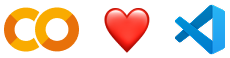

Try the new <a href="https://marketplace.visualstudio.com/items?itemName=Google.colab">Google Colab extension</a> for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the <strong><em>Extensions</em></strong> view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any <code>.ipynb</code> notebook file in your local workspace and either running a cell or clicking the <strong><em>Select kernel</em></strong> button in the top right.
*  Click <strong><em>Colab</em></strong> and then select your desired runtime, sign in with your Google Account and you're all set!

See more details in our <a href="https://developers.googleblog.com/google-colab-is-coming-to-vs-code">announcement blog here</a>.

## 🎁 Free-of-charge Pro plan for Gemini and Colab for US university students 🎓

Get more access to our most accurate model Gemini 3 Pro for advanced coding, complex research and innovative projects, backed by Colab's dedicated high-compute resources for data science and machine learning.

Get the Gemini free-of-charge offer at <a href="https://gemini.google/students?utm_source=colab&amp;utm_medium=banner&amp;utm_campaign=students_xpa_us-colab-banner">gemini.google/students</a>.  
Get the Colab free-of-charge offer at <a href="https://colab.research.google.com/signup">colab.research.google.com/signup</a>.  
Terms apply.

## Access popular AI models via Google Colab-AI without an API key
All users have access to most popular LLMs via the <code>google-colab-ai</code> Python library, and paid users have access to a wider selection of models. For more details, refer to <a href="https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb">getting started with Google Colab AI</a>.



In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")
print(response)

## Explore the Gemini API
The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code and audio.

**How to get started**
*  Go to <a href="https://aistudio.google.com/">Google AI Studio</a> and log in with your Google Account.
*  <a href="https://aistudio.google.com/app/apikey">Create an API key</a>.
* Use a quickstart for <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb">Python</a> or call the REST API using <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb">curl</a>.

**Discover Gemini's advanced capabilities**
*  Play with Gemini <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb">multimodal outputs</a>, mixing text and images in an iterative way.
*  Discover the <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb">multimodal Live API</a> &#40;demo <a href="https://aistudio.google.com/live">here</a>&#41;.
*  Learn how to <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb&quot;">analyse images and detect items in your pictures</a> using Gemini &#40;bonus, there's a <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb">3D version</a> as well!&#41;.
*  Unlock the power of the <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb">Gemini thinking model</a>, capable of solving complex tasks with its inner thoughts.
      
**Explore complex use cases**
*  Use <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb">Gemini grounding capabilities</a> to create a report on a company based on what the model can find on the Internet.
*  Extract <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb">invoices and form data from PDFs</a> in a structured way.
*  Create <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb">illustrations based on a whole book</a> using Gemini large context window and Imagen.

To learn more, take a look at the <a href="https://github.com/google-gemini/cookbook">Gemini cookbook</a> or visit the <a href="https://ai.google.dev/docs/">Gemini API documentation</a>.


Colab now has AI features powered by <a href="https://gemini.google.com">Gemini</a>. The video below provides information on how to use these features, whether you're new to Python or a seasoned veteran.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  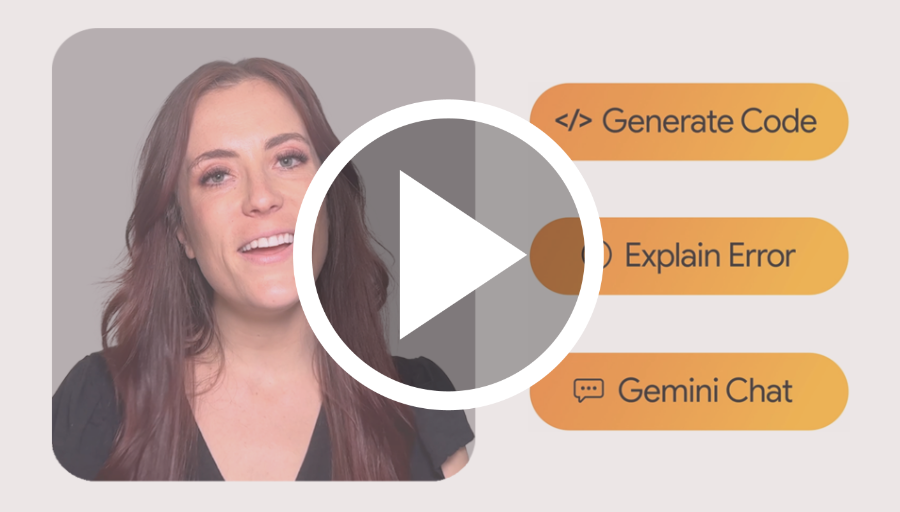
  </a>
</center>

<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or ‘Colaboratory’, allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a <strong>student</strong>, a <strong>data scientist</strong> or an <strong>AI researcher</strong>, Colab can make your work easier. Watch <a href="https://www.youtube.com/watch?v=inN8seMm7UI">Introduction to Colab</a> or <a href="https://www.youtube.com/watch?v=rNgswRZ2C1Y">Colab features you may have missed</a> to learn more or just get started below!

<div class="markdown-google-sans">

## <strong>Getting started</strong>
</div>

The document that you are reading is not a static web page, but an interactive environment called a <strong>Colab notebook</strong> that lets you write and execute code.

For example, here is a <strong>code cell</strong> with a short Python script that computes a value, stores it in a variable and prints the result:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut 'Command/Ctrl+Enter'. To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine <strong>executable code</strong> and <strong>rich text</strong> in a single document, along with <strong>images</strong>, <strong>HTML</strong>, <strong>LaTeX</strong> and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To find out more, see <a href="/notebooks/basic_features_overview.ipynb">Overview of Colab</a>. To create a new Colab notebook you can use the File menu above, or use the following link: <a href="http://colab.research.google.com#create=true">Create a new Colab notebook</a>.

Colab notebooks are Jupyter notebooks that are hosted by Colab. To find out more about the Jupyter project, see <a href="https://www.jupyter.org">jupyter.org</a>.

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyse and visualise data. The code cell below uses <strong>numpy</strong> to generate some random data, and uses <strong>matplotlib</strong> to visualise it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from GitHub and many other sources. To find out more about importing data, and how Colab can be used for data science, see the links below under <a href="#working-with-data">Working with data</a>.

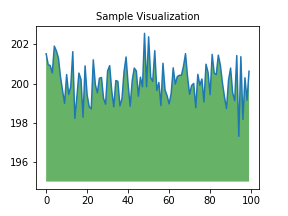

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning that you can leverage the power of Google hardware, including <a href="#using-accelerated-hardware">GPUs and TPUs</a>, regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for <strong>pandas</strong> code to finish running and want to go faster, you can switch to a GPU runtime and use libraries like <a href="https://rapids.ai/cudf-pandas">RAPIDS cuDF</a> that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb">10-minute guide</a> or
 <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb">US stock market data analysis demo</a>.

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it and evaluate the model, all in just <a href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb">a few lines of code</a>.

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the <a href="#machine-learning-examples">machine learning examples</a> below.

<div class="markdown-google-sans">

## More resources

### Working with notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with data
</div>

- [Loading data: Drive, Sheets and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualising data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine learning

<div>

These are a few of the notebooks related to machine learning, including Google's online machine learning course. See the <a href="https://developers.google.com/machine-learning/crash-course/">full course website</a> for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)
- [Linear regression with tf.keras using synthetic data](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/linear_regression_with_synthetic_data.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using accelerated hardware
</div>

- [TensorFlow with GPUs](/notebooks/gpu.ipynb)
- [TPUs in Colab](/notebooks/tpu.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- <a href="https://tensorflow.org/hub/tutorials/tf2_image_retraining">Retraining an Image Classifier</a>: Build a Keras model on top of a pre-trained image classifier to distinguish flowers.
- <a href="https://tensorflow.org/hub/tutorials/tf2_text_classification">Text Classification</a>: Classify IMDB film reviews as either <em>positive</em> or <em>negative</em>.
- <a href="https://tensorflow.org/hub/tutorials/tf2_arbitrary_image_stylization">Style Transfer</a>: Use deep learning to transfer style between images.
- <a href="https://tensorflow.org/hub/tutorials/retrieval_with_tf_hub_universal_encoder_qa">Multilingual Universal Sentence Encoder Q&amp;A</a>: Use a machine-learning model to answer questions from the SQuAD dataset.
- <a href="https://tensorflow.org/hub/tutorials/tweening_conv3d">Video Interpolation</a>: Predict what happened in a video between the first and the last frame.
